# Fitting NGC1068 in the image plane

In [1]:
# jax ecosystem
import jax
from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

/home/max/code/amigo/src/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

source_name = "NGC1068"
data_path = os.path.join(path, f"data/JWST/{source_name}/new_calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

dorito.misc.truncate_files(sci_files, 4)

In [4]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}'
    )
    t0 = t


------------------------------

NGC1068 F480M, Dither 1/5, Roll 273.0deg, 2.3min, 2024-09-16 22:09:19.803, Groups: 20, Ints: 91
NGC1068 F480M, Dither 2/5, Roll 273.0deg, 2.3min, 2024-09-16 22:12:17.915, Groups: 20, Ints: 91
NGC1068 F480M, Dither 3/5, Roll 273.0deg, 2.3min, 2024-09-16 22:15:16.219, Groups: 20, Ints: 91
NGC1068 F480M, Dither 4/5, Roll 273.0deg, 2.3min, 2024-09-16 22:18:15.483, Groups: 20, Ints: 91
NGC1068 F480M, Dither 5/5, Roll 273.0deg, 2.3min, 2024-09-16 22:21:13.595, Groups: 20, Ints: 91
HD 228337 F480M, Dither 1/5, Roll 266.8deg, 0.8min, 2024-09-16 23:43:14.381, Groups: 6, Ints: 103
HD 228337 F480M, Dither 2/5, Roll 266.8deg, 0.8min, 2024-09-16 23:44:42.509, Groups: 6, Ints: 103
HD 228337 F480M, Dither 3/5, Roll 266.8deg, 0.8min, 2024-09-16 23:46:10.573, Groups: 6, Ints: 103
HD 228337 F480M, Dither 4/5, Roll 266.8deg, 0.8min, 2024-09-16 23:47:38.573, Groups: 6, Ints: 103
HD 228337 F480M, Dither 5/5, Roll 266.8deg, 0.8min, 2024-09-16 23:49:06.637, Groups: 6, Ints: 1

/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Building the model

In [5]:
class DynamicResolvedFit(dorito.model_fits.ResolvedFit):
    """
    Model fit for resolved sources where each exposure has a different
    intensity distribution.
    """

    def get_key(self, param):
        match param:
            case "log_distribution":
                return "_".join([self.key, self.filter])

        return super().get_key(param)


class YearPointFit(amigo.model_fits.PointFit):
    date: str  # isot
    year: str

    def __init__(self, file, use_cov=True):
        expmid = Time(file[0].header["EXPMID"], format="mjd")
        self.date = str(expmid.isot)
        self.year = f"{expmid.ymdhms[0]:04d}"
        super().__init__(file, use_cov=use_cov)

    def get_key(self, param):
        # Return the per exposure key if not joint fitting
        match param:
            case "aberrations":
                return "_".join([self.year, self.filter])

        return super().get_key(param)

    def print_summary(self):
        print(
            # f"File {self.key}\n"
            f"Star {self.star}\n"
            f"Filter {self.filter}\n"
            f"Parang {self.parang:.2f} deg\n"
            f"Dither {self.dither}\n"
            f"Date {self.date}\n"
            # f"nints {self.nints}\n"
            # f"ngroups {len(self.slopes)+1}\n"
        )


class YearResolvedFit(dorito.model_fits.ResolvedFit):

    date: str  # isot
    year: str

    def __init__(self, file, use_cov=True):
        expmid = Time(file[0].header["EXPMID"], format="mjd")
        self.date = str(expmid.isot)
        self.year = f"{expmid.ymdhms[0]:04d}"
        super().__init__(file, use_cov=use_cov)

    def get_key(self, param):
        # Return the per exposure key if not joint fitting
        match param:
            case "aberrations":
                return "_".join([self.year, self.filter])

        return super().get_key(param)

    def print_summary(self):
        print(
            # f"File {self.key}\n"
            f"Star {self.star}\n"
            f"Filter {self.filter}\n"
            f"Parang {self.parang:.2f} deg\n"
            f"Dither {self.dither}\n"
            f"Date {self.date}\n"
            # f"nints {self.nints}\n"
            # f"ngroups {len(self.slopes)+1}\n"
        )

In [6]:
source_size = 121  # pixels
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

sci_fits = [
    YearResolvedFit(file, use_cov=True)
    for file in sci_files
    # DynamicResolvedFit(file, source_size, use_cov=True) for file in sci_files
]
cal_fits = [YearPointFit(file, use_cov=True) for file in cal_files]

# I only want to use the calibrator in the same primary dither position
# fits = cal_fits[0:1]
# fits = [fit for fit in sci_fits if fit.dither == "1"] + [
#     fit for fit in cal_fits if fit.dither == "1"
# ]
# fits = sci_fits[0:1] + cal_fits[0:1]
fits = [sci_fits[0], sci_fits[-1], cal_fits[0], cal_fits[-1]]

# fits = sci_fits + cal_fits

# building the model
model = dorito.models.ResolvedAmigoModel(
    exposures=fits,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
    param_initers={
        "distribution": np.ones((source_size, source_size)) / source_size**2
    },
)

Star NGC1068
Filter F480M
Parang 272.96 deg
Dither 1
Date 2024-09-16T22:09:19.803



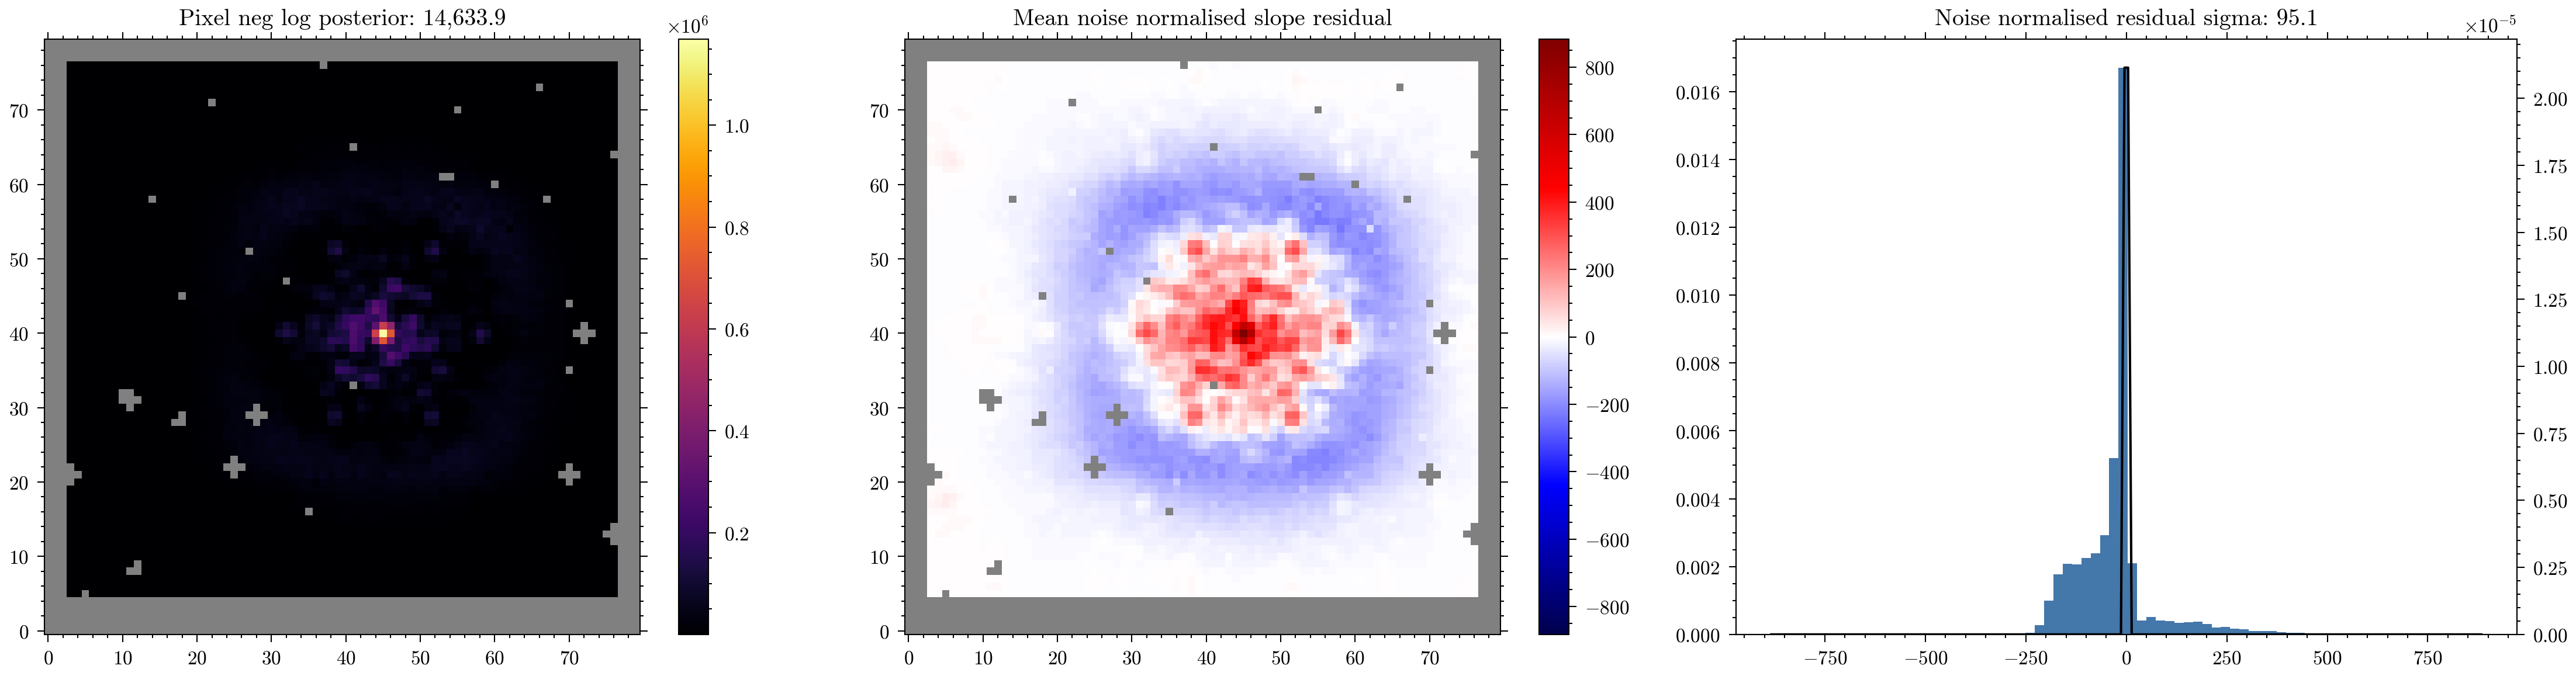

Star NGC1068
Filter F480M
Parang 257.96 deg
Dither 5
Date 2025-08-13T17:47:54.418



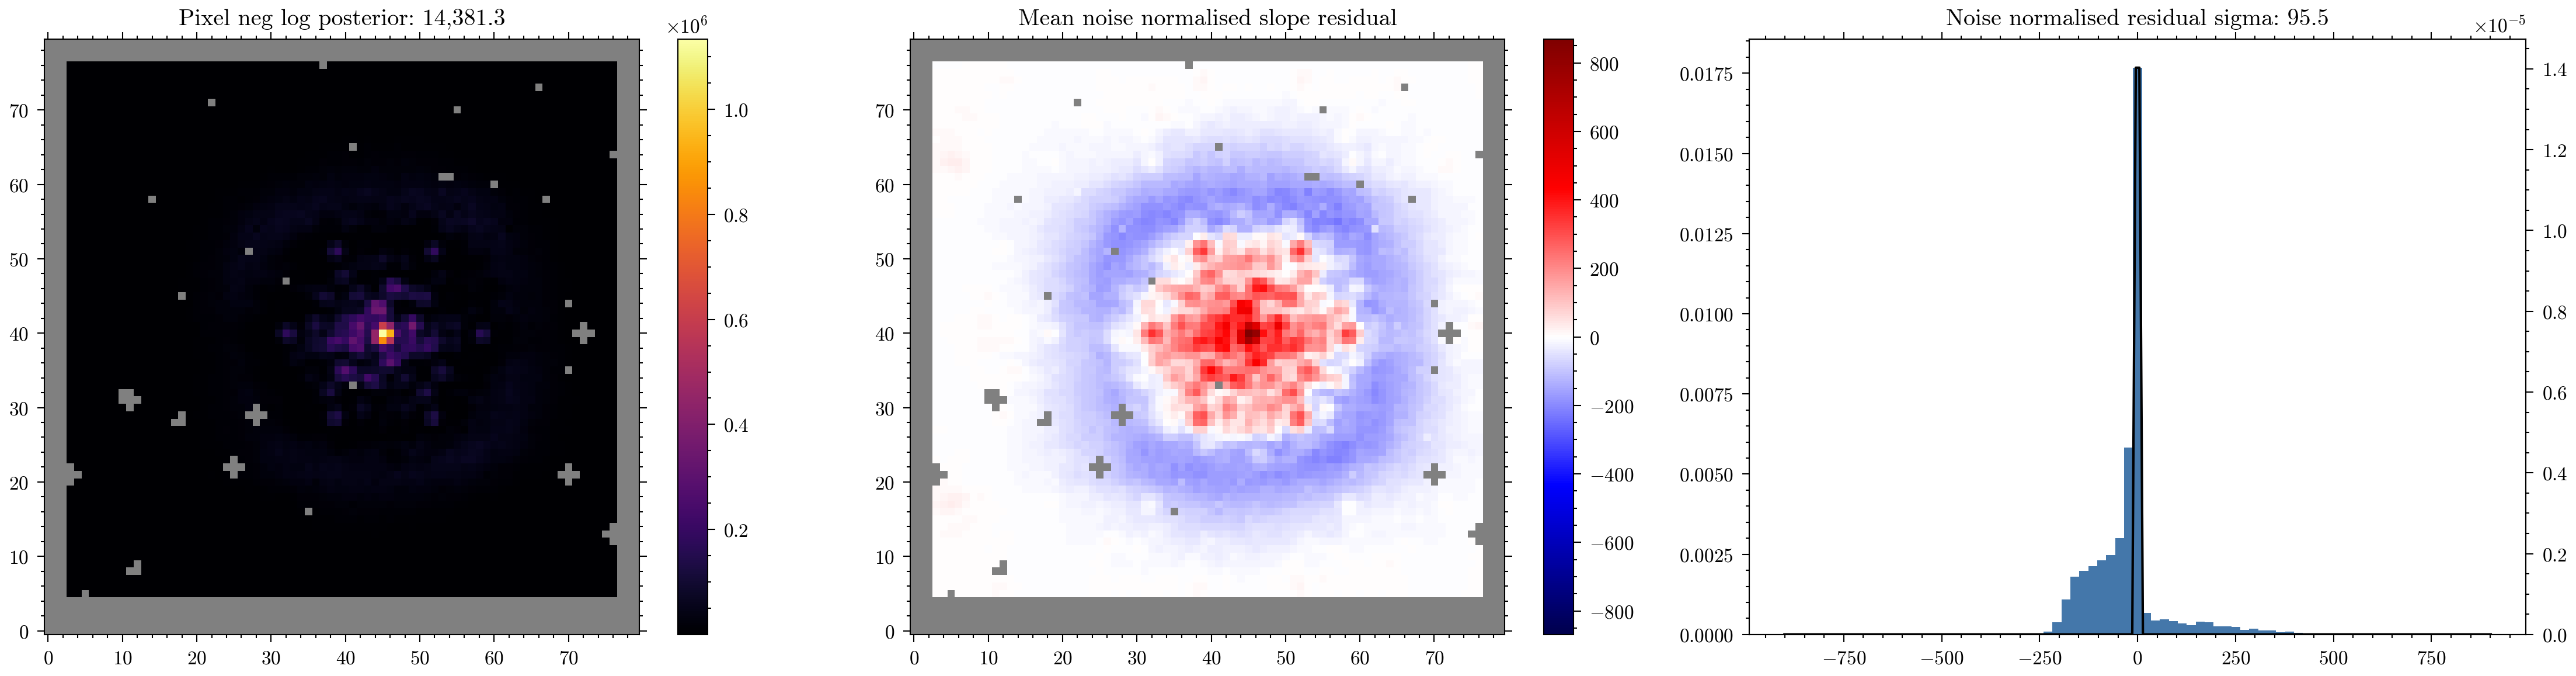

Star HD 228337
Filter F480M
Parang 266.78 deg
Dither 1
Date 2024-09-16T23:43:14.381



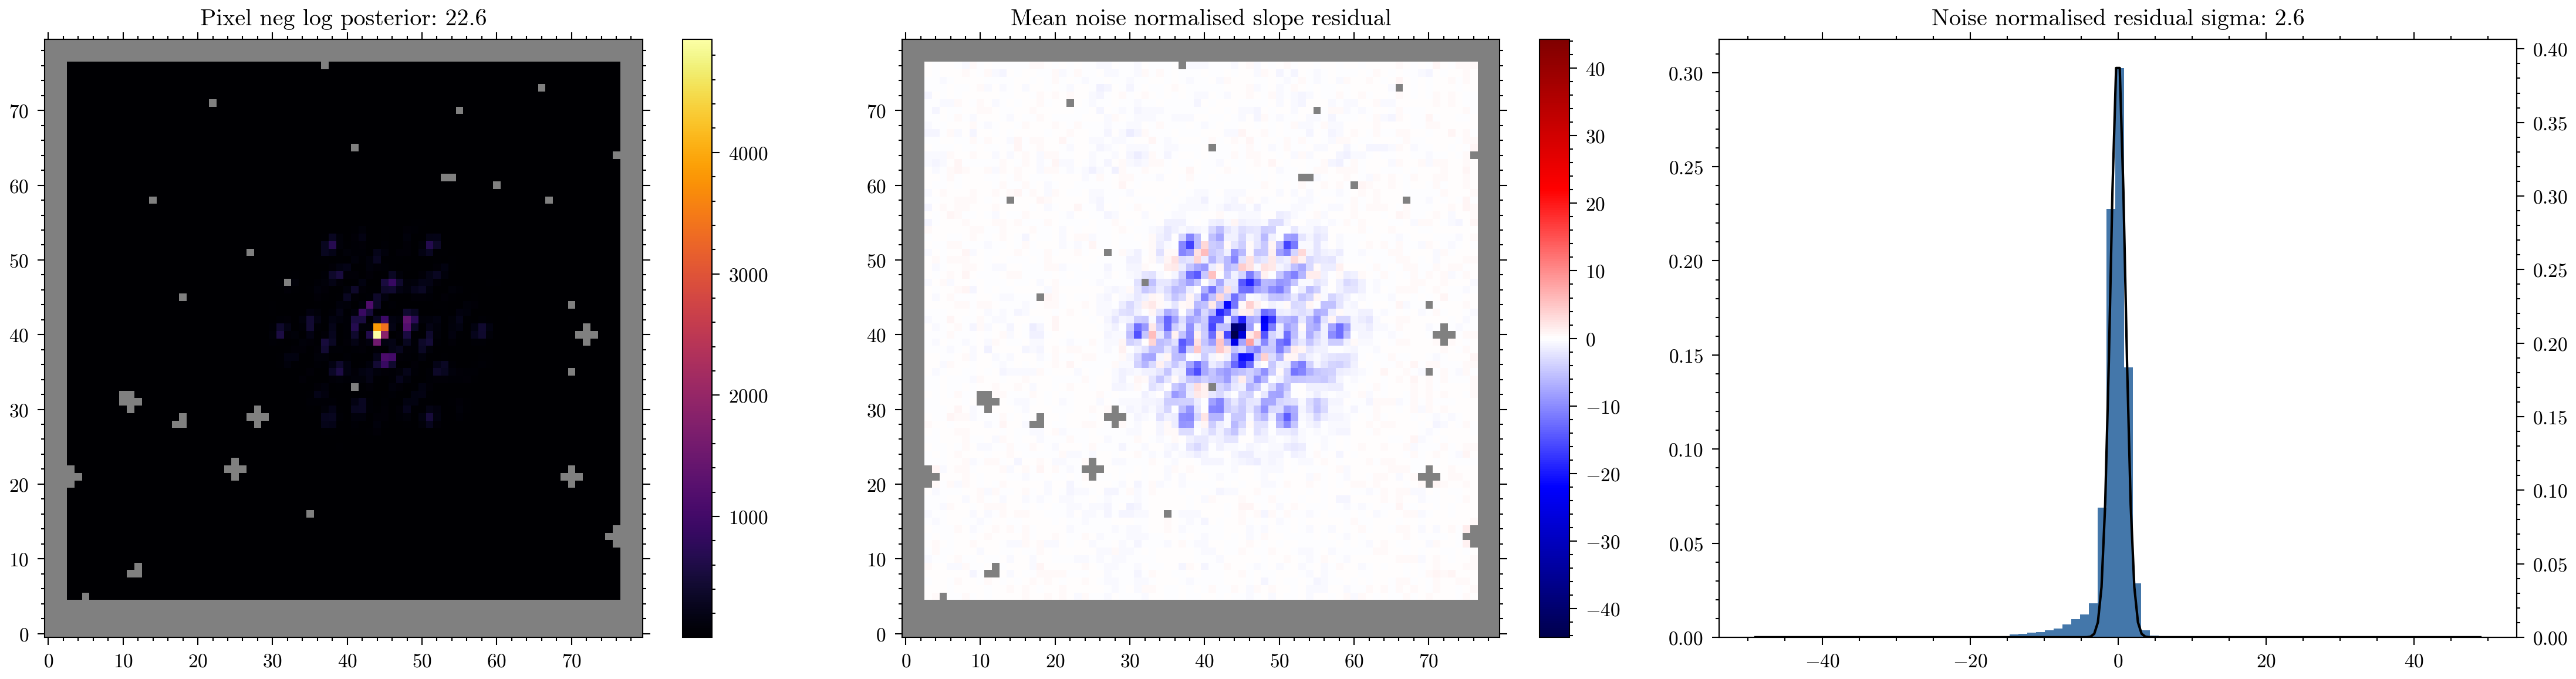

Star HD 228337
Filter F480M
Parang 254.99 deg
Dither 5
Date 2025-08-13T18:43:33.750



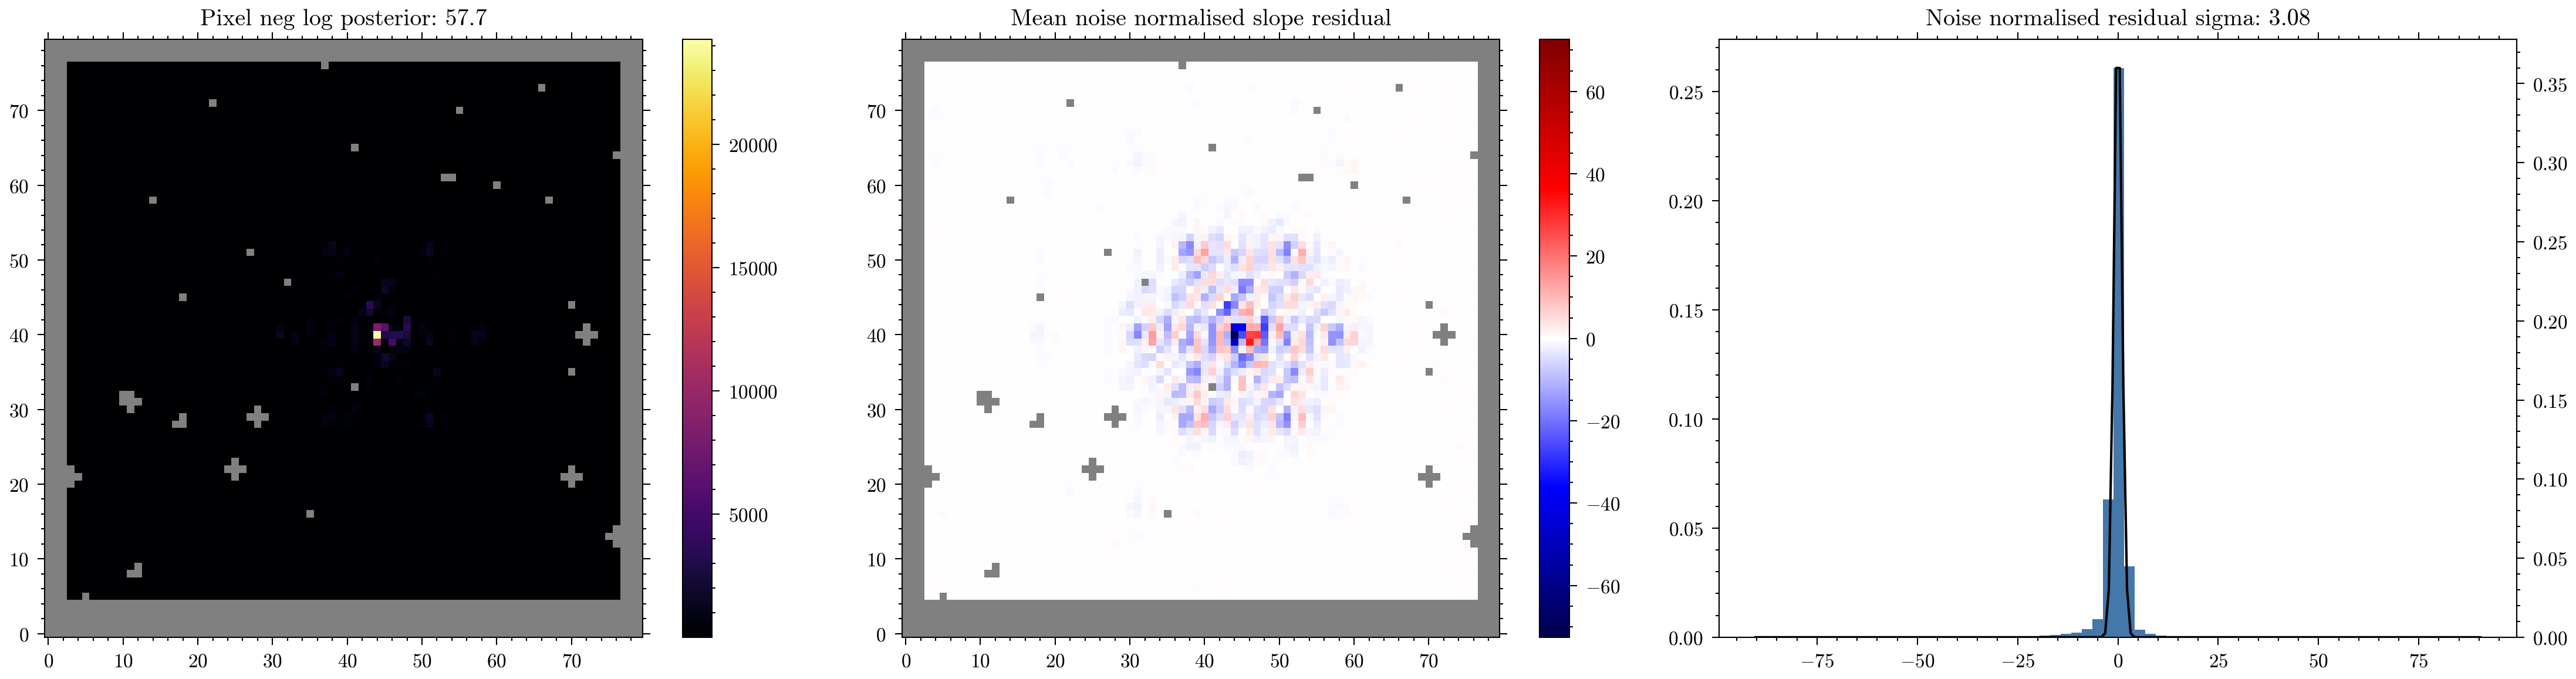

In [7]:
for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

## Optimisation Stage 1: Gradient Descent

In [8]:
pos_keys = []
spc_keys = []
for exp in fits:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def norm_fn(model_params, args):
    params = model_params.params
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist
            params["log_dist"][k] = np.log10(distribution / distribution.sum())

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample

In [15]:
n_epoch = 300

config = {
    "positions": sgd(5e-2, 0),
    "fluxes": sgd(5e-2, 5),
    "aberrations": sgd(2e-1, 10),
    "log_dist": adam(1e-1, 10, (1000, 0.75)),
    "spectra": sgd(2e-1, 50),
    # "amplitudes": sgd(5e-1, 50),
    # "phases": sgd(5e-1, 50),
}


def grad_fn(model, grads, args):
    # Nuke the position gradients for the science exposures
    if "positions" in config.keys():
        grads = grads.multiply(pos_keys, 0.1)

    # Reduce spectra gradients for the science exposures
    if "spectra" in config.keys():
        grads = grads.multiply(spc_keys, 0.3)
    return grads, args


args = {
    "reg_dict": {
        # "L1": dorito.stats.L1_on_wavelets,
        # "L1": L1_REG,
        # "QV": dorito.stats.TSV,
        # 1e4: dorito.stats.TV,
        "ME": (1e3, dorito.stats.ME),
    }
}

trainer = amigo.fitting.Trainer(
    # loss_fn=dorito.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    fits,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys()],  # if p not in ["log_dist"]],
)

print("Number of exposures: ", len(fits))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
)

Populating fishers...
KeyError: log_dist not in hessians for 01260_103_02_03_1, skipped
KeyError: log_dist not in hessians for 01260_001_02_03_5, skipped
KeyError: log_dist not in hessians for 01260_104_02_03_1, skipped
KeyError: log_dist not in hessians for 01260_002_02_03_5, skipped
Number of exposures:  4


  0%|          | 0/300 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 7,267.37
Estimated run time: 0:03:43
Full Time: 0:04:25
Final Loss: 23.38


In [16]:
# np.save("good_ngc.npy", dist)

In [17]:
# np.save(output_path + "params.npy", result.model.params, allow_pickle=True)
result_model = result.model

# params = np.load(output_path + "allgoodrun_params.npy", allow_pickle=True).item()
# result_model = model.set("params", params)

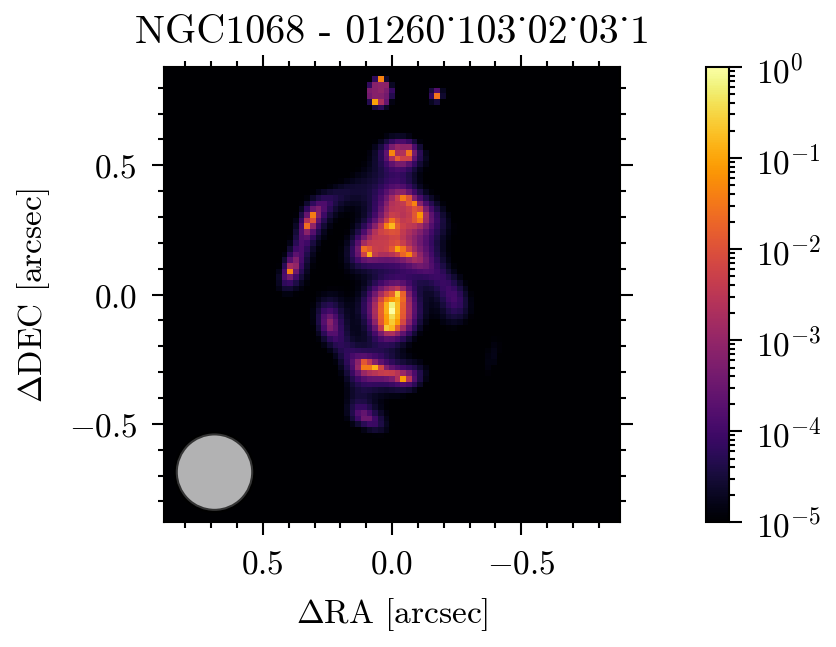

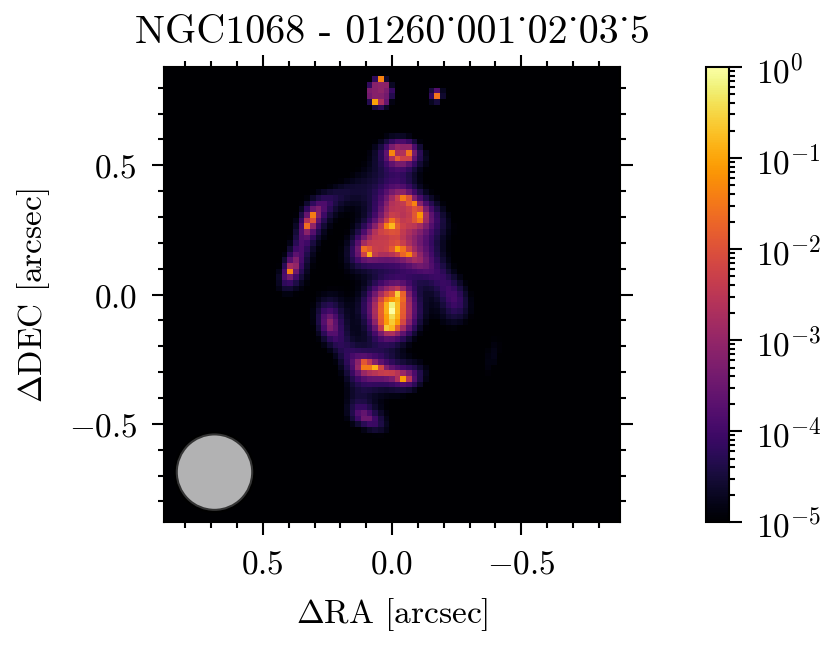

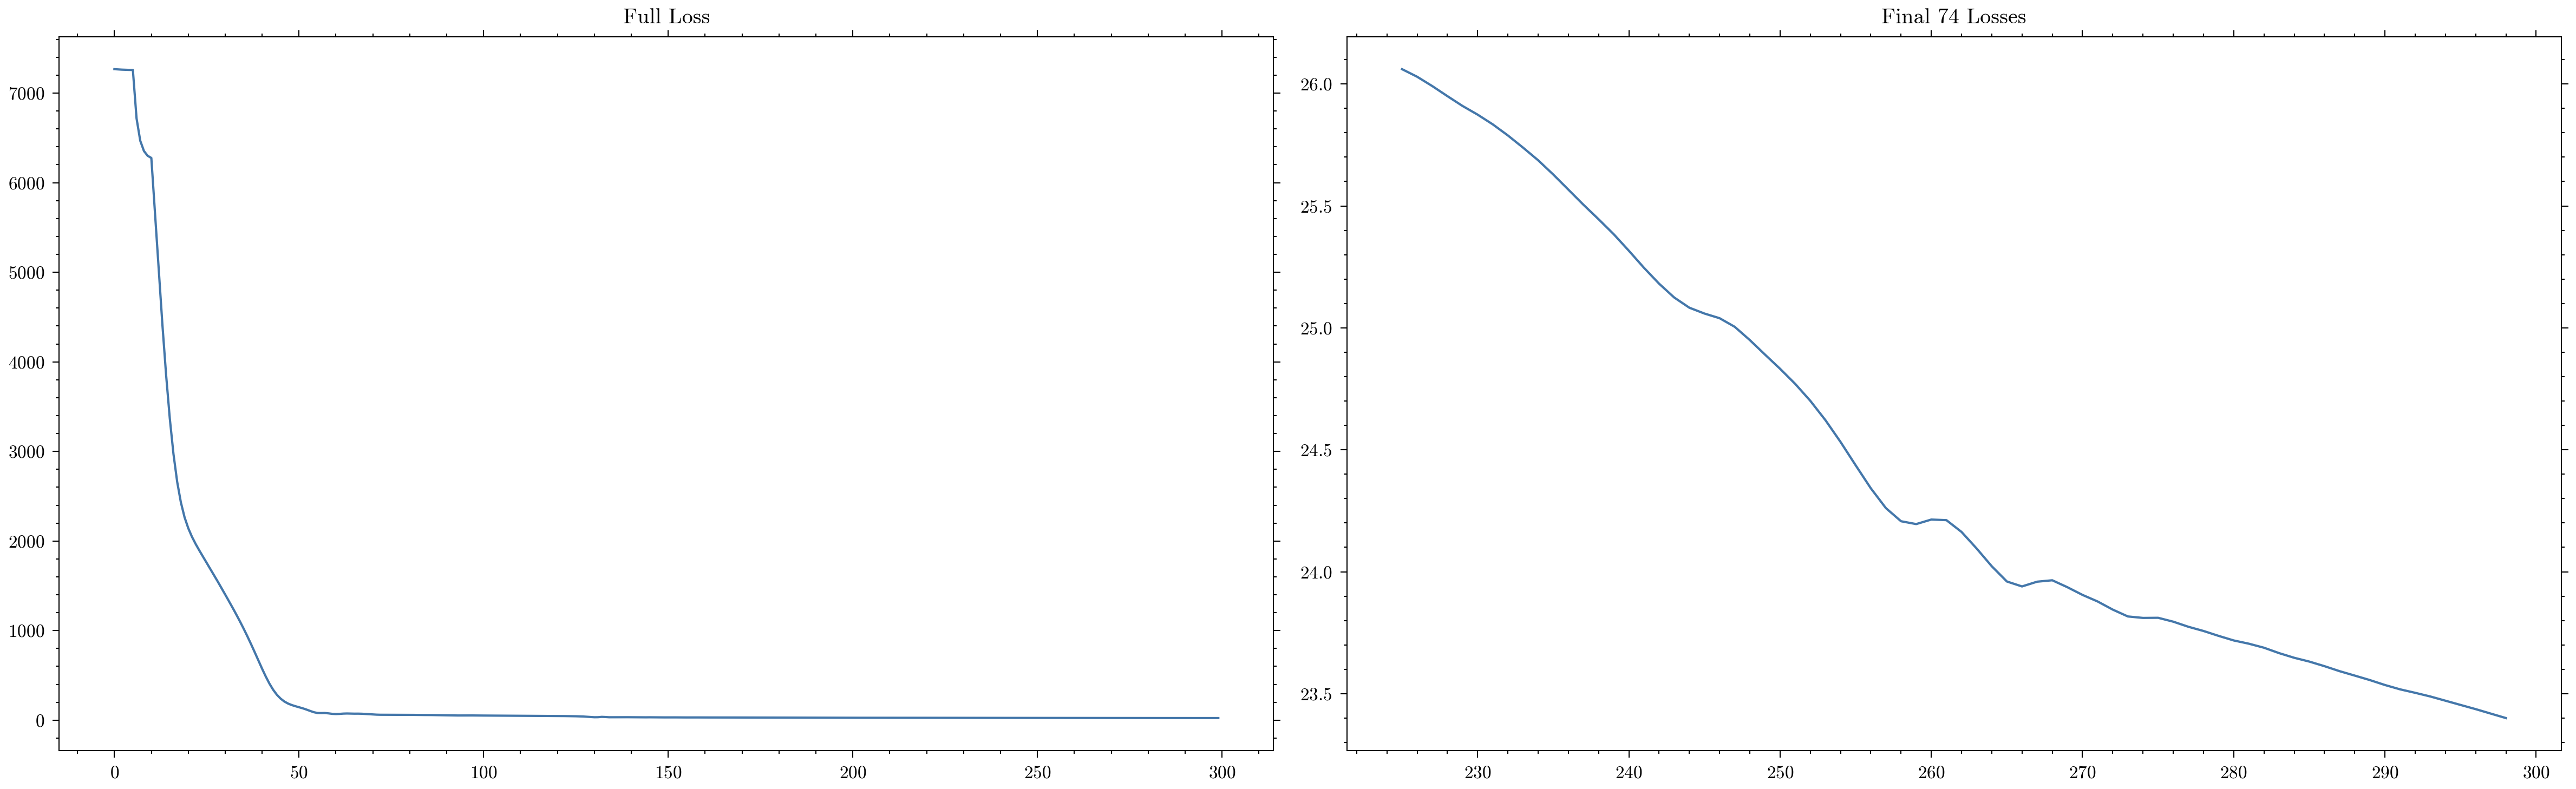

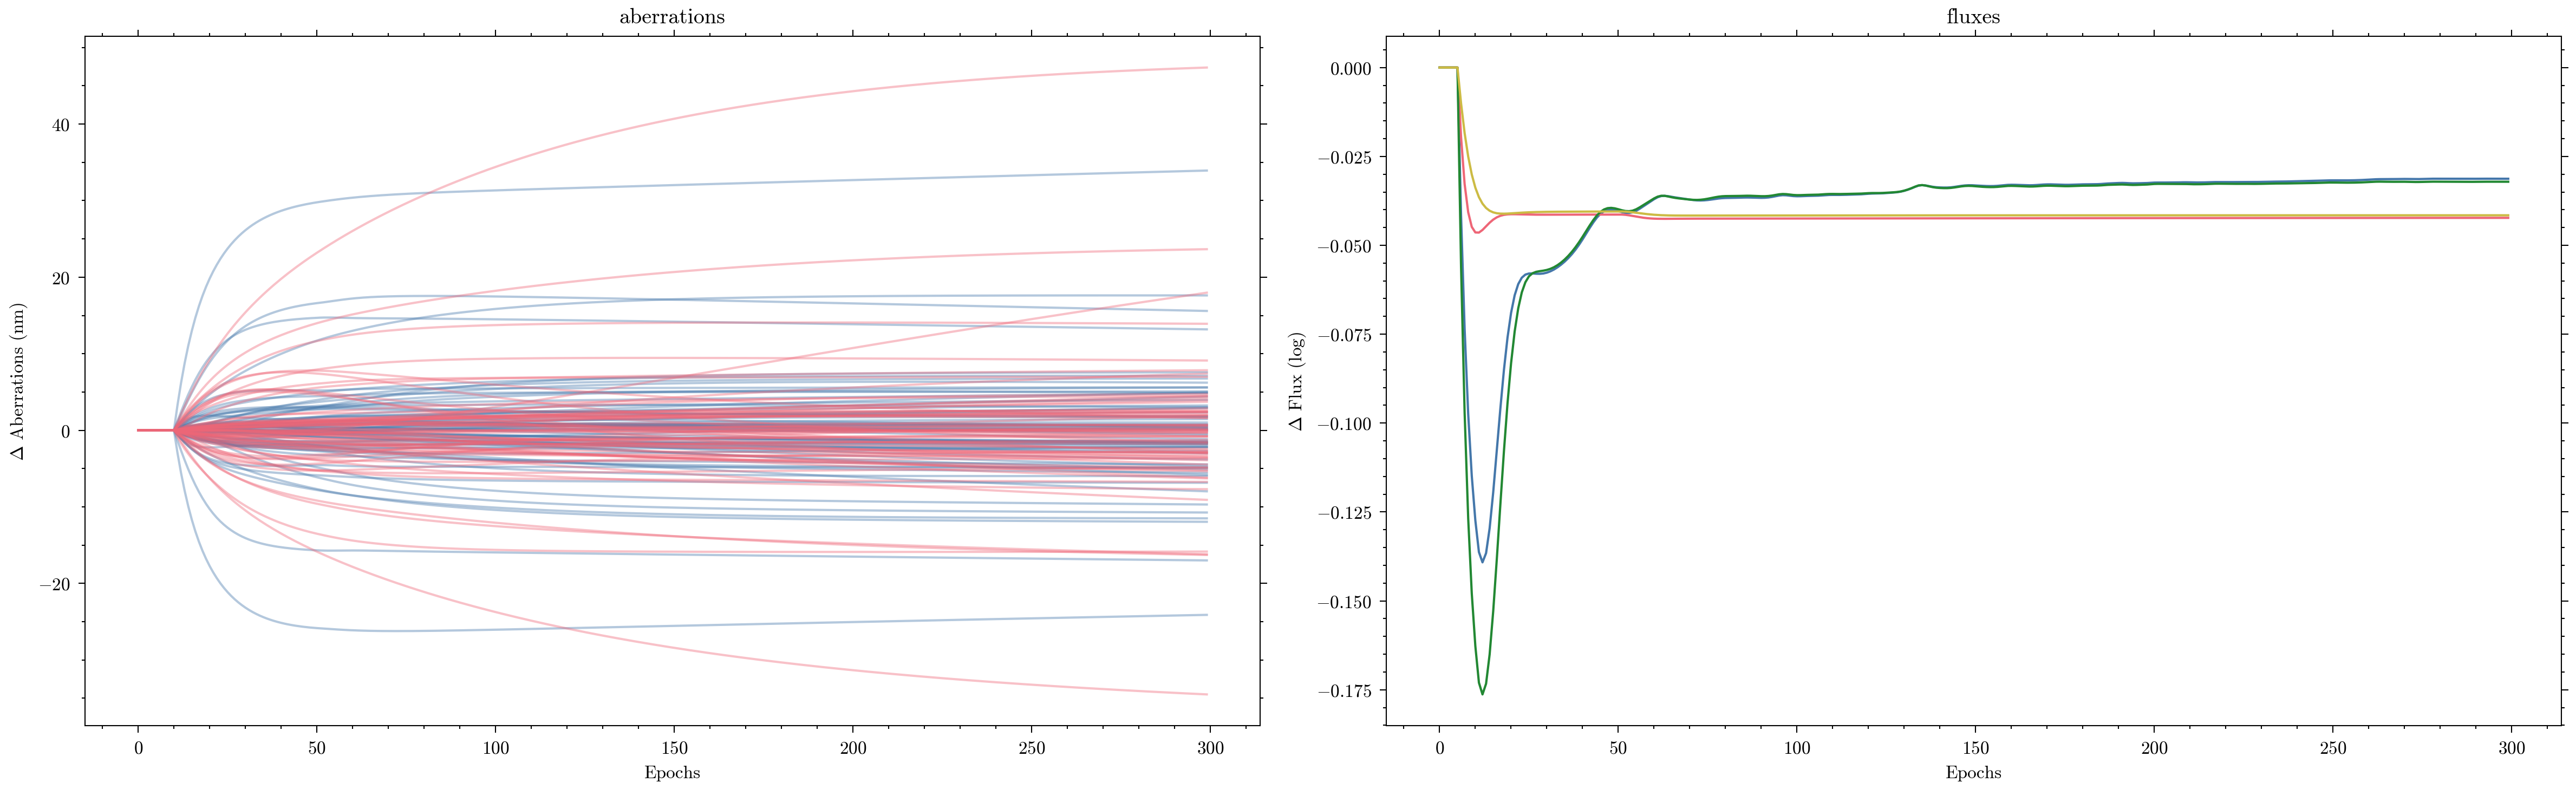

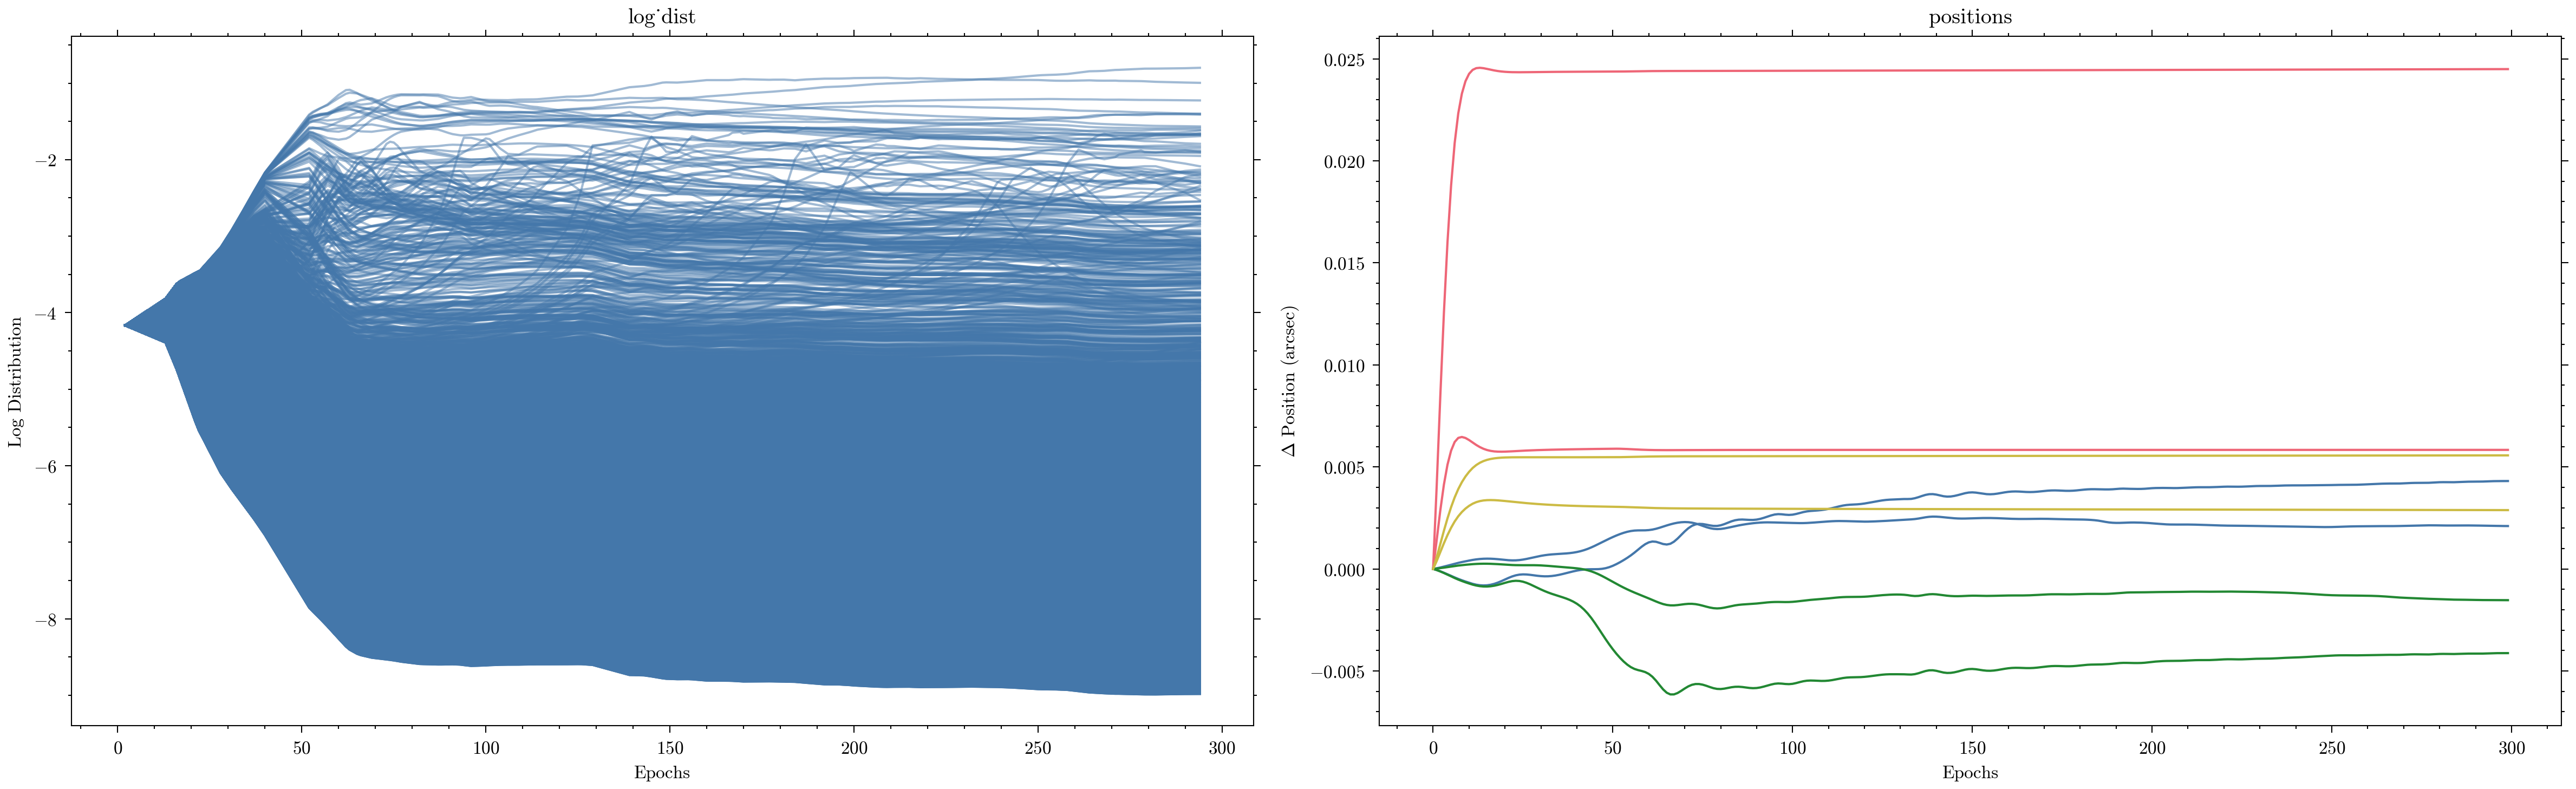

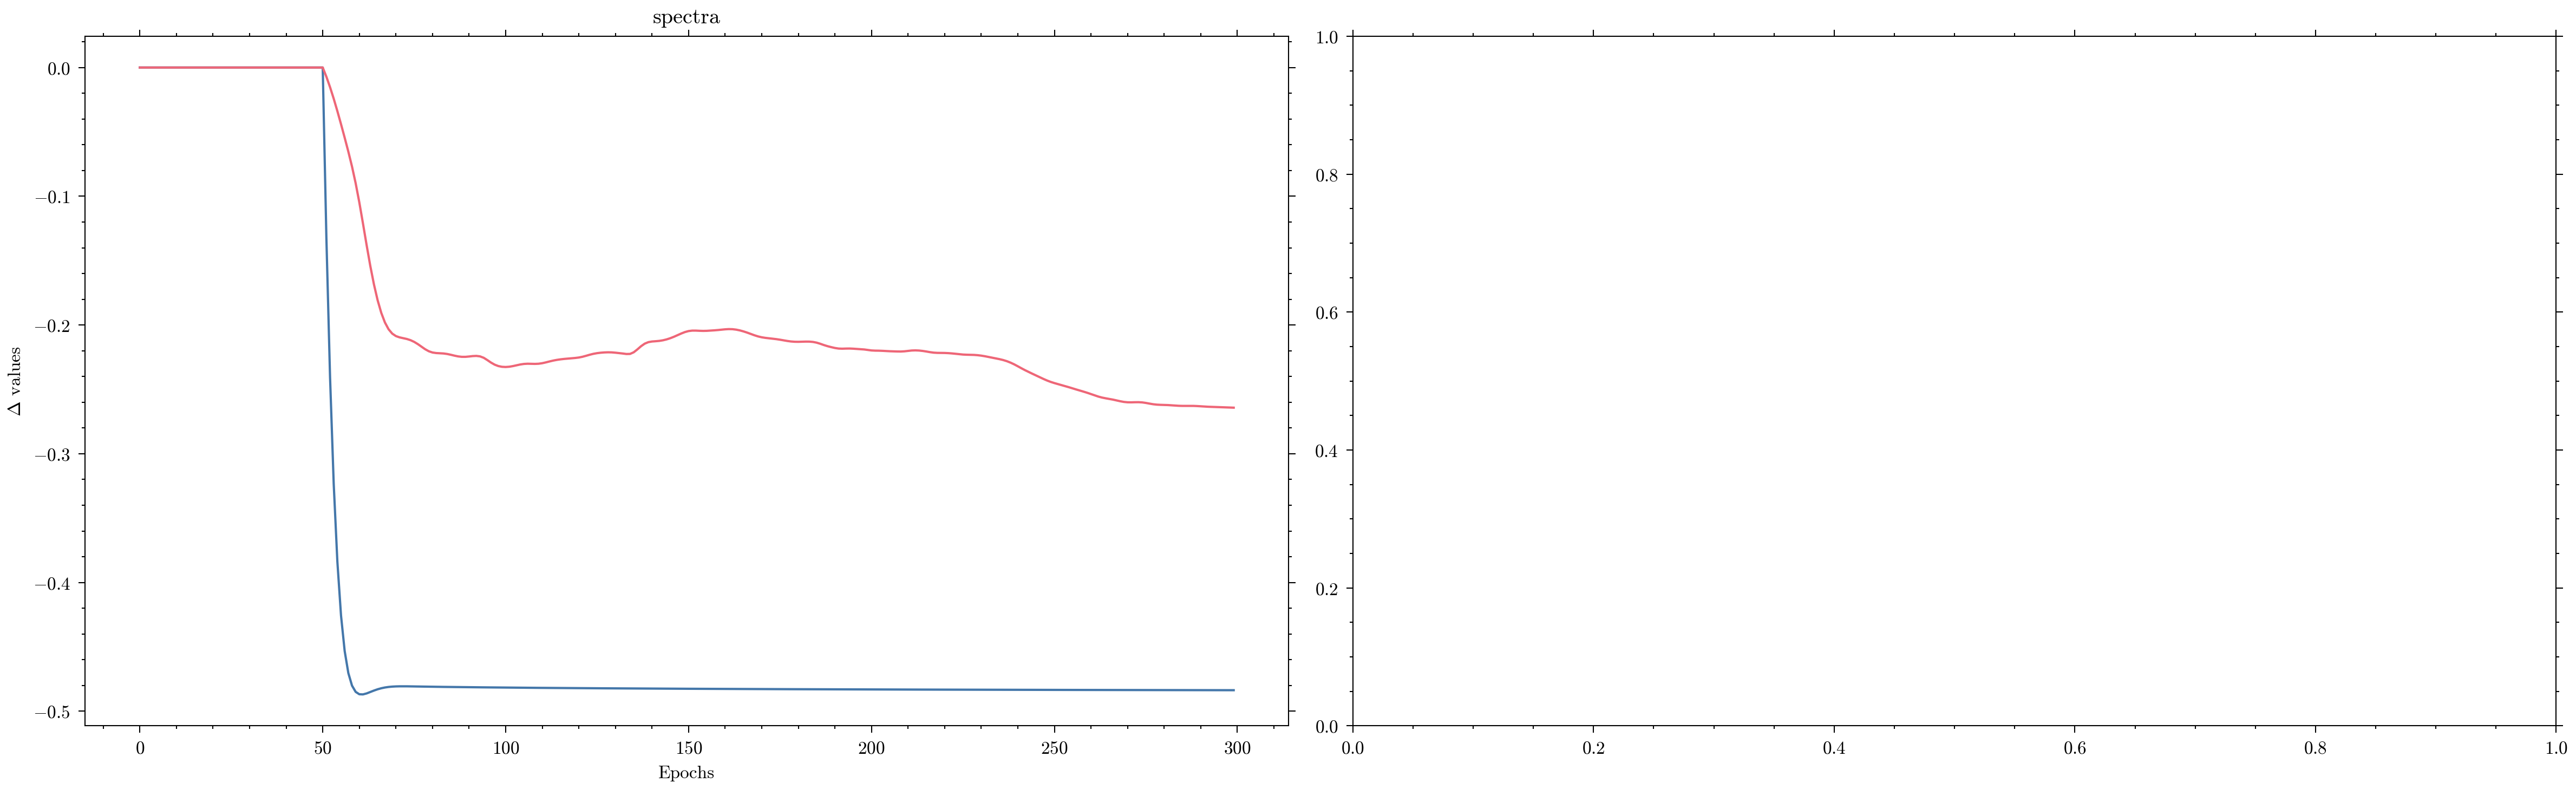

Star NGC1068
Filter F480M
Parang 272.96 deg
Dither 1
Date 2024-09-16T22:09:19.803



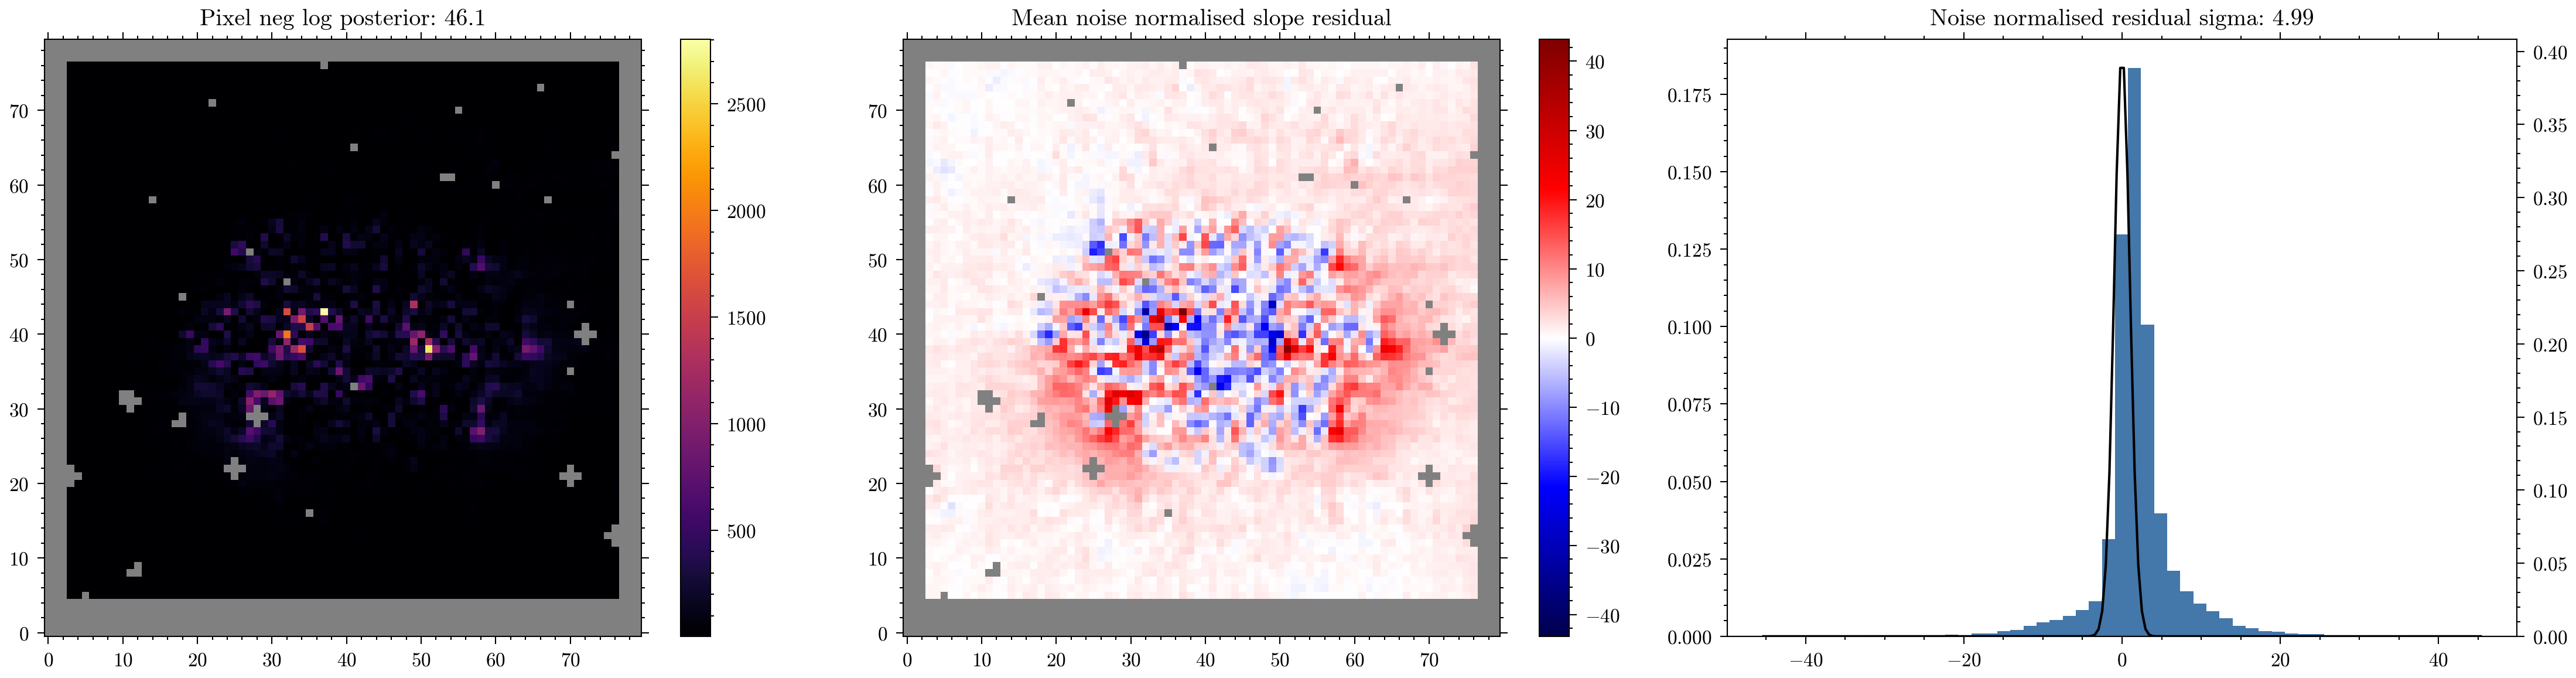

Star NGC1068
Filter F480M
Parang 257.96 deg
Dither 5
Date 2025-08-13T17:47:54.418



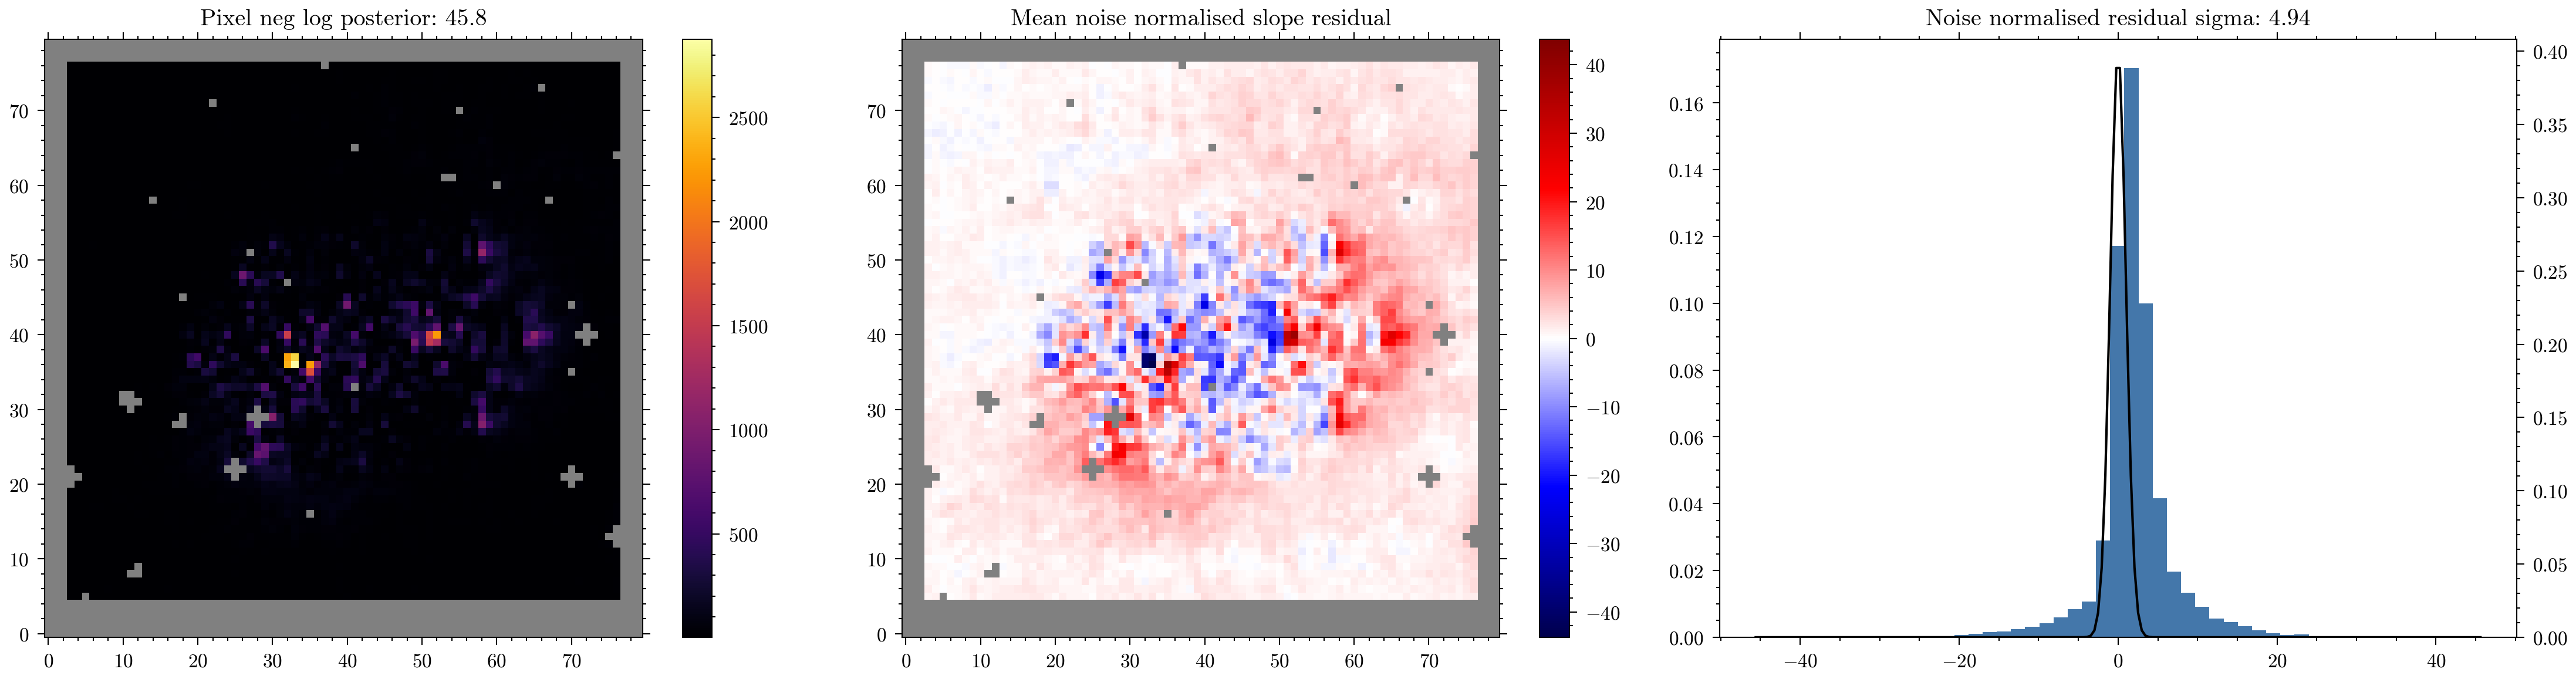

Star HD 228337
Filter F480M
Parang 266.78 deg
Dither 1
Date 2024-09-16T23:43:14.381



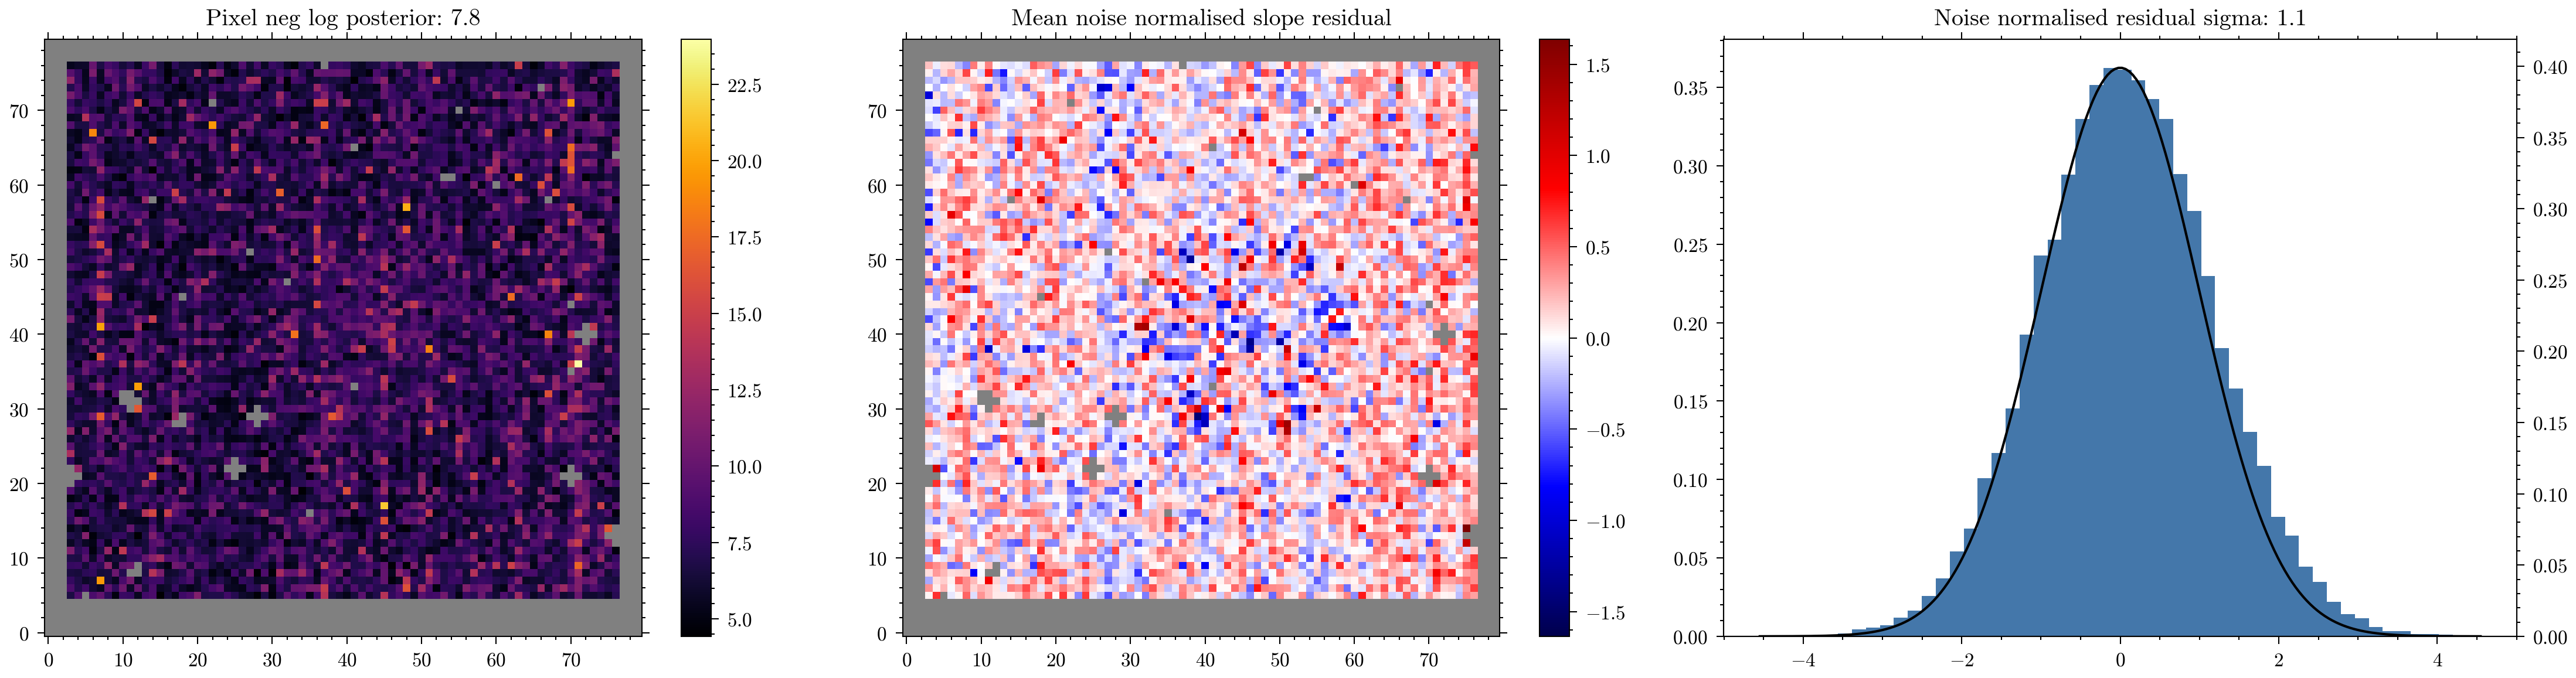

Star HD 228337
Filter F480M
Parang 254.99 deg
Dither 5
Date 2025-08-13T18:43:33.750



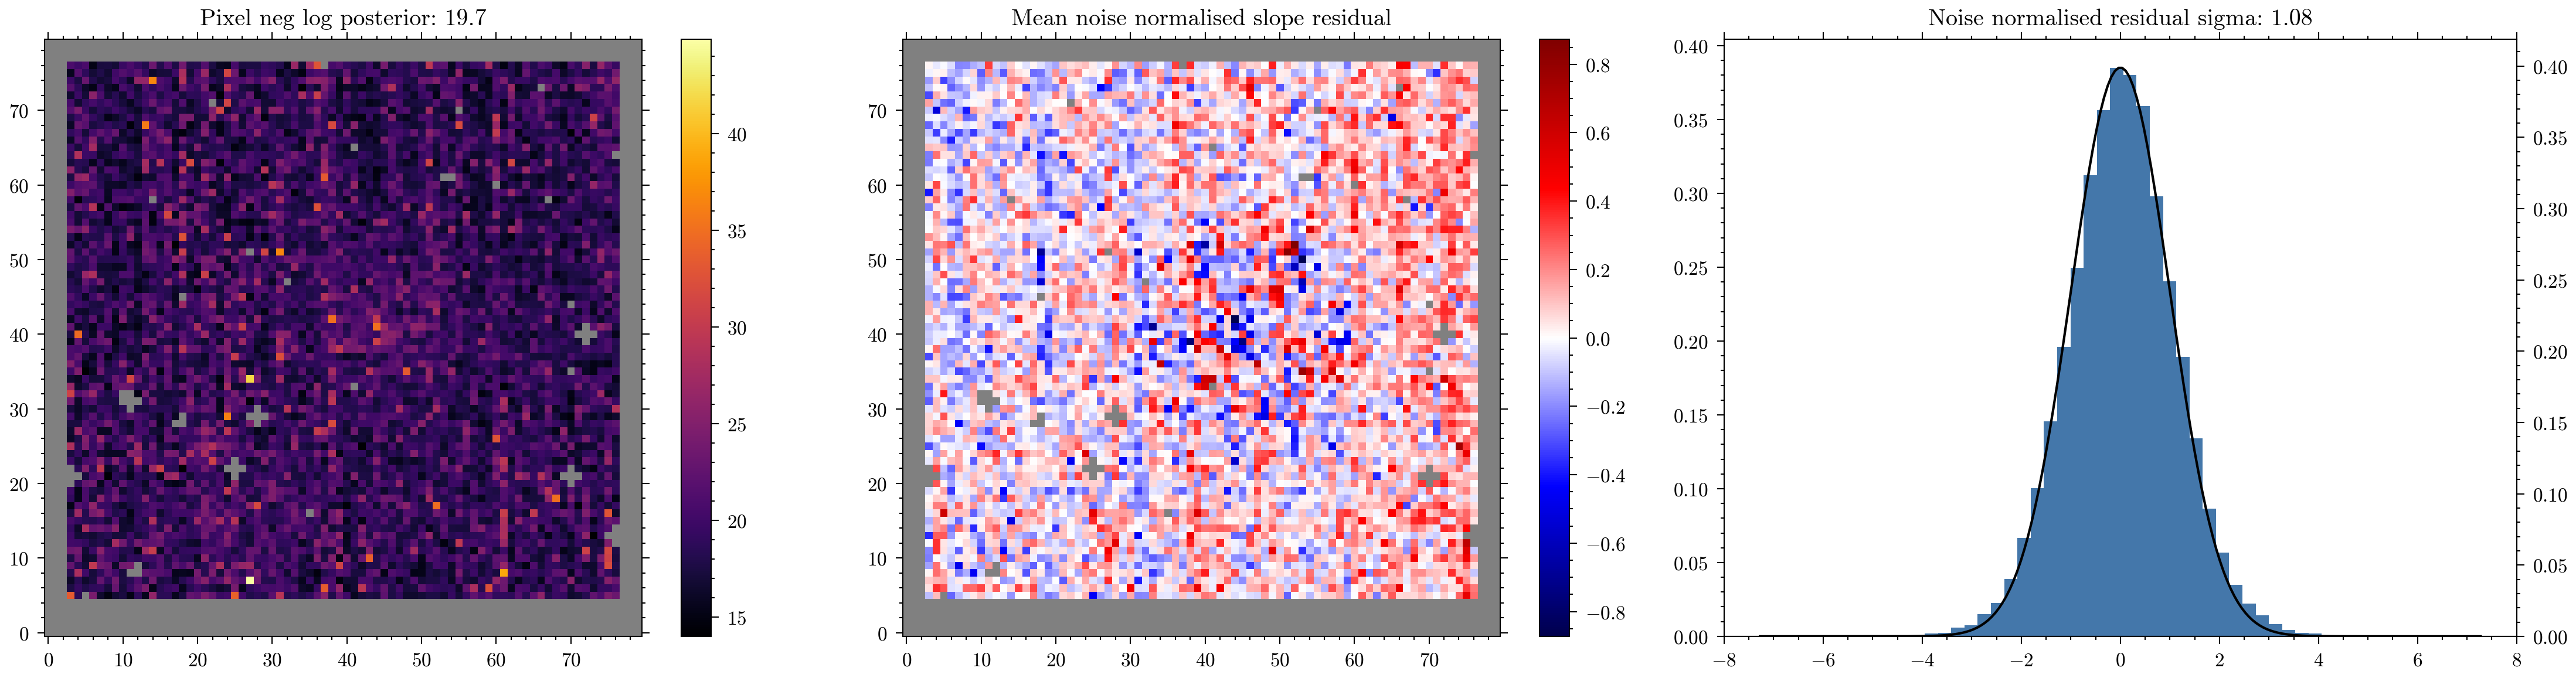

In [18]:
from dLux import utils as dlu

optics_diameter = 6.603464  # JWST aperture diameter in meters

wavel = 4.8e-6

for exp in fits:

    if exp.calibrator:
        continue
    dist = result_model.get_distribution(exp, rotate=False)
    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist / dist.max(),
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        # roll_angle_degrees=-exp.parang,
        norm=mpl.colors.LogNorm(vmin=1e-5),
        # norm=mpl.colors.PowerNorm(0.3, vmax=0.3),
        diff_lim=dlu.rad2arcsec(wavel / optics_diameter),
        scale=1.5,
    )

    fig.colorbar(c0)

    ax.set(title=f"NGC1068 - {exp.key}")  #   xticks=ticks, yticks=ticks)

    plt.tight_layout()
    # plt.show()
    plt.savefig(output_path + f"{exp.key}_dist.png", dpi=300)

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

In [14]:
from scipy.ndimage import gaussian_filter

pixel_scale = model.psf_pixel_scale / model.oversample

r, g, b = [
    result_model.get_distribution(exp, rotate=False)
    * (10 ** result_model.params["fluxes"][exp.get_key("fluxes")])
    for exp in fits
    if not exp.calibrator
]
# * result_model.params["fluxes"][exp.get_key("fluxes")]

# r = (
#     result_model.get_distribution(fits[0], rotate=False)
#     * result_model.params["fluxes"][fits[0]]
# )
# g = result_model.get_distribution(fits[1], rotate=False)
# b = result_model.get_distribution(fits[2], rotate=False)

eff_wavel = np.array(
    [np.dot(*model.filters[exp.filter]) for exp in fits if exp.calibrator is False]
).mean()


def blur(factor, arr, filter):

    # wavelength in metres
    wavel = np.dot(*model.filters[filter])

    # FWHM in pixels
    lambda_over_d = dlu.rad2arcsec(wavel / model.optics.diameter)  # arcseconds
    lambda_over_d /= pixel_scale  # pixels
    fwhm = factor * lambda_over_d
    sigma = float(fwhm / (2 * (2 * np.log(2)) ** 0.5))

    return gaussian_filter(arr, sigma=(sigma))


fac = 0.25  # factor to scale the FWHM
r = blur(fac, r, "F480M")
g = blur(fac, g, "F430M")
b = blur(fac, b, "F380M")

piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**0.5  # adjust brightness
piccy = np.clip(piccy, 0, 0.2)  # remove negative values
piccy /= piccy.max()

# piccy = np.log10(piccy)
# piccy = np.clip(piccy, -4.5, None)
# piccy -= piccy.min()
# piccy /= piccy.max()
# piccy = piccy**0.2

fig, ax = plt.subplots(figsize=(3, 2.5))

c0 = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=pixel_scale,  # arcseconds/pixel
    scale=1.25,
    # norm=mpl.colors.LogNorm(),
    diff_lim=dlu.rad2arcsec(eff_wavel / model.optics.diameter),
    # ticks=[-0.5, 0, 0.5],
    ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)


# Arrow parameters
arrow_length = 15 * pixel_scale  # in pixels
origin = -0.95, -0.95  # starting point of arrows (in pixel coords)

# Draw North arrow
ax.annotate(
    "",
    xy=(origin[0], origin[1] + arrow_length),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0],
    origin[1] + arrow_length + 2 * pixel_scale,
    "N",
    color="white",
    ha="center",
    va="bottom",
    fontsize=8,
)

# Draw East arrow
ax.annotate(
    "",
    xy=(origin[0] + arrow_length, origin[1]),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0] + arrow_length + 6 * pixel_scale,
    origin[1],
    "E",
    color="white",
    ha="left",
    va="center",
    fontsize=8,
)


ax.set(title=f"NGC1068 False Colour")
plt.tight_layout()
# plt.savefig(output_path + "ngc_1068_false_colour.png", dpi=500, bbox_inches="tight")
plt.show()

ValueError: not enough values to unpack (expected 3, got 2)

## Optimisation Stage 2: BFGS

In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args
    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


def bfgs_solve(model, exposures, params, rtol=1e-6, atol=1e-6, max_steps=2048):

    args_out = {}
    sols_out = {}

    for exp in exposures:
        print(f"Solving for {exp.key}...")
        opt_params = {}
        fishers = {}
        shapes = {}

        for param in params:
            # print()
            key = exp.map_param(param)
            try:
                shapes[key] = model.get(key).shape
            except AttributeError:
                print(model.get(key))
                raise AttributeError(
                    f"Parameter {key} not found in final model. Check the parameter name."
                )
            opt_params[key] = model.get(key).flatten()

            new_key = ".".join([exp.key, param])

            if new_key in trainer.fishers.keys():
                fishers[key] = trainer.fishers[f"{exp.key}.{param}"]
            else:
                print(f"Did not find {key} in fishers, setting to one...")
                fishers[key] = np.eye(opt_params[key].size)
                continue

        shapes = ModelParams(shapes)
        model_params = ModelParams(opt_params)
        initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
        proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
        proj_mats = jtu.map(
            lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats
        )
        args = (model, exp, model_params, proj_mats, shapes)
        args_out[exp.key] = args

        print("Initial loss:", fun(initial_params, args))
        solver = optx.BFGS(rtol=rtol, atol=atol)
        sol = optx.minimise(
            fun,
            solver,
            initial_params,
            args,
            throw=False,
            max_steps=max_steps,
        )
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    return sols_out, args_out

In [ ]:
final_model = result.model

cal_params = ["positions", "fluxes", "aberrations", "spectra"]
cal_sols_out, cal_args_out = bfgs_solve(final_model, cal_fits, cal_params)

for key, args in cal_args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, cal_sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

Solving for 01260_104_02_03_1...
Initial loss: 3.4717833750862592
Final loss: 3.452927039023147
219 156


Solving for 01260_104_02_03_2...


KeyError: '01260_104_02_03_2'

In [ ]:
sci_params = ["fluxes", "log_dist", "spectra"]
sci_sols_out, sci_args_out = bfgs_solve(
    final_model, sci_fits, sci_params, rtol=1e-10, atol=1e-10
)

spectra = {}
for key, args in sci_args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sci_sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model.spectra[exp.get_key("spectra")] = spectra[exp.get_key("spectra")]

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

Solving for 01373_017_02_04_1...
Did not find log_distribution.01373_017_02_04_1_F430M in fishers, setting to one...
Initial loss: 21.84447864809328
Final loss: 21.54529357931579
14 8


Solving for 01373_017_02_04_2...
Did not find log_distribution.01373_017_02_04_2_F430M in fishers, setting to one...
Initial loss: 19.099233891044133
Final loss: 18.91866791421039
31 12


Solving for 01373_017_02_04_3...
Did not find log_distribution.01373_017_02_04_3_F430M in fishers, setting to one...
Initial loss: 21.88993401114943
Final loss: 21.58750592592007
17 7


Solving for 01373_017_02_04_4...
Did not find log_distribution.01373_017_02_04_4_F430M in fishers, setting to one...
Initial loss: 21.751376549198067
Final loss: 21.44982584902649
34 9


Solving for 01373_017_02_04_5...
Did not find log_distribution.01373_017_02_04_5_F430M in fishers, setting to one...
Initial loss: 21.44746786449858
Final loss: 21.16129789616557
32 10




F430M Science IO 18
Loss: 21.545


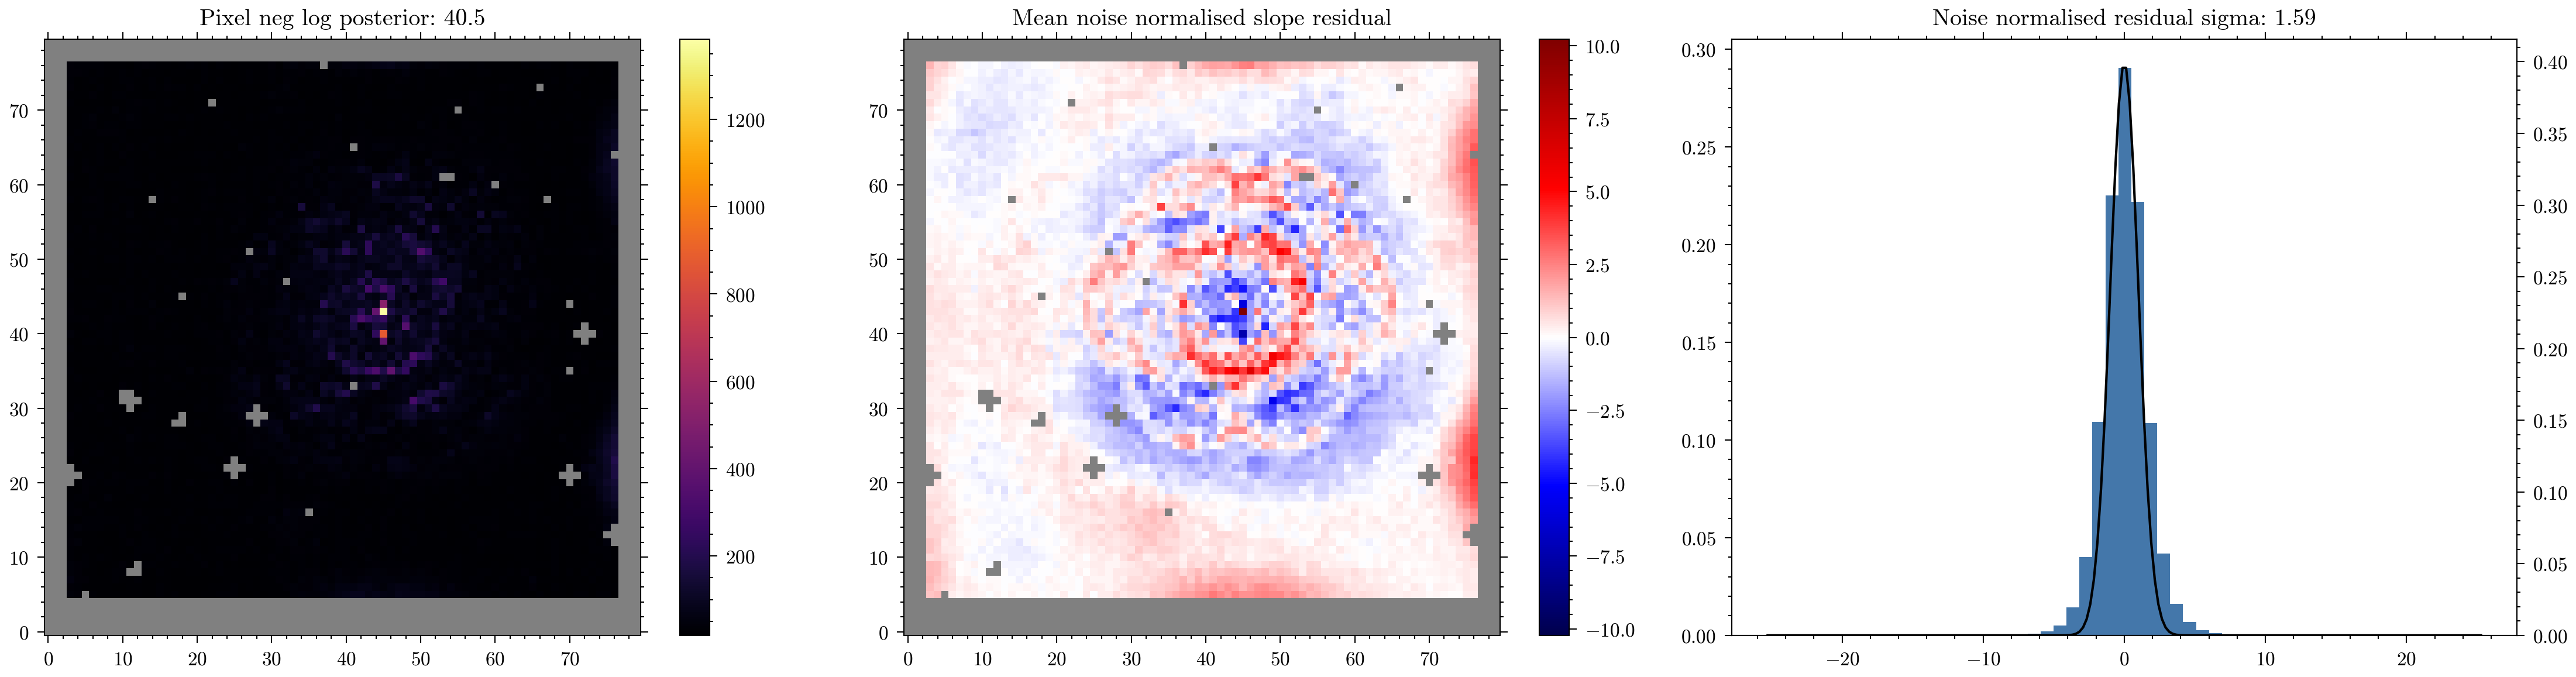

F430M Science IO 18
Loss: 18.920


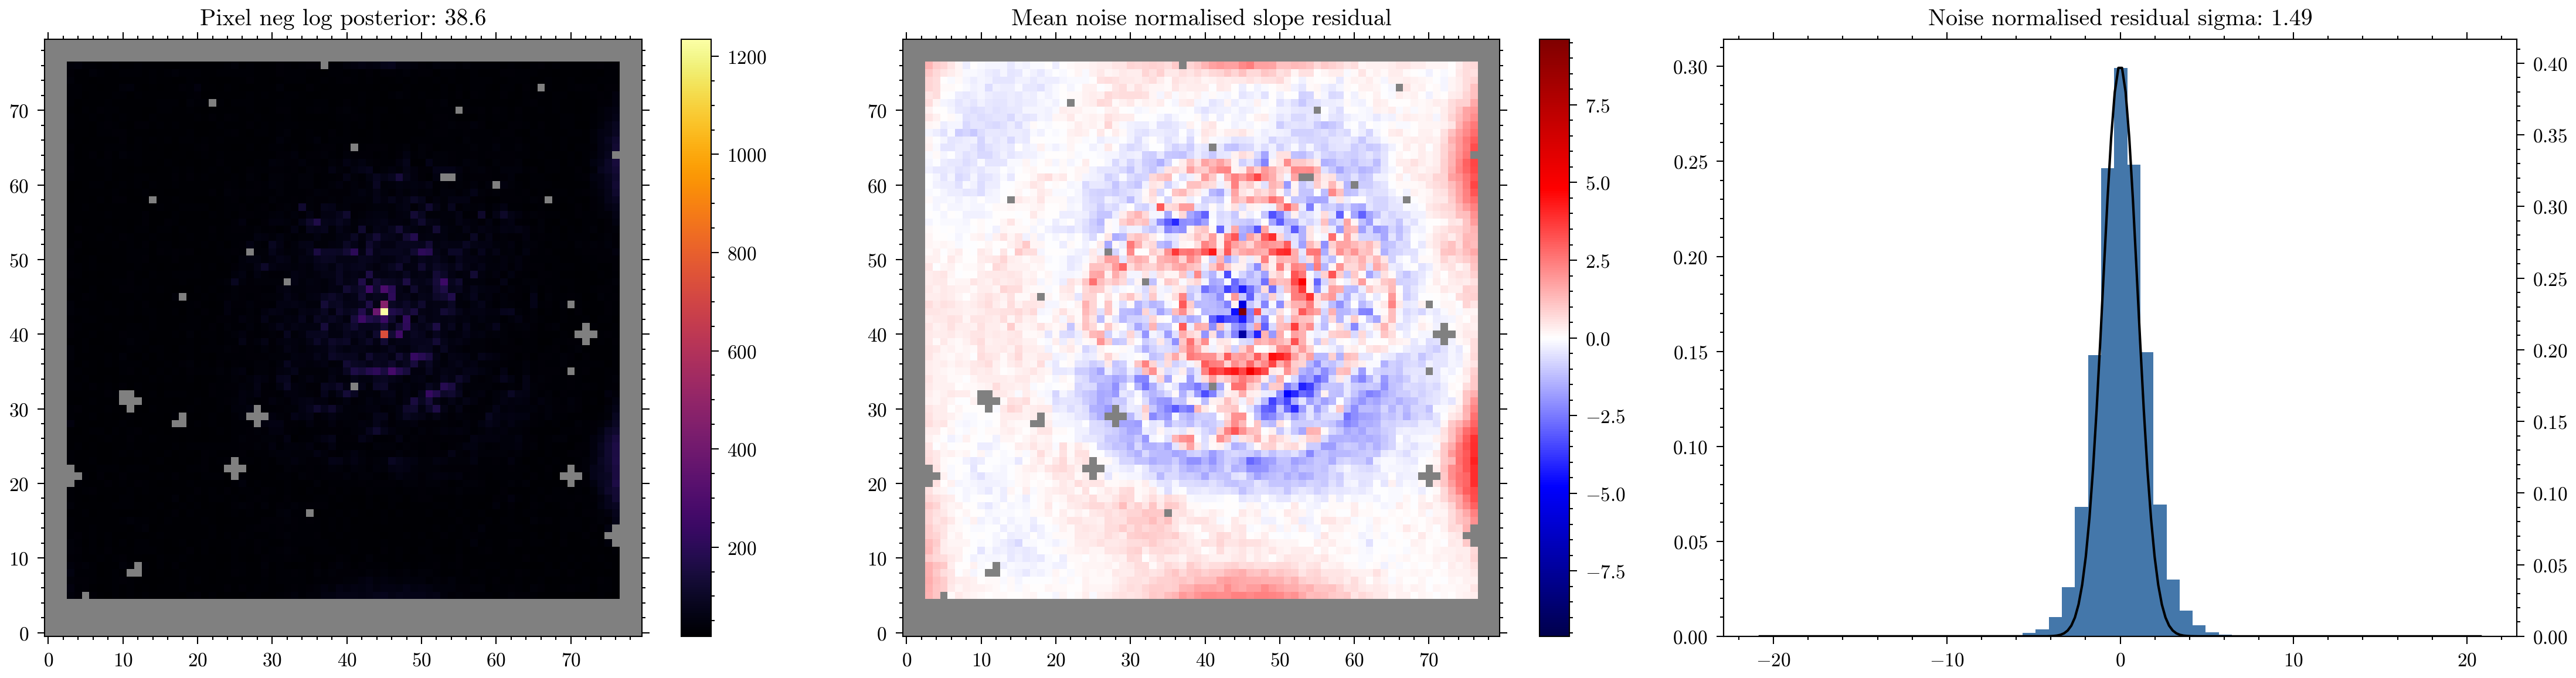

F430M Science IO 18
Loss: 21.588


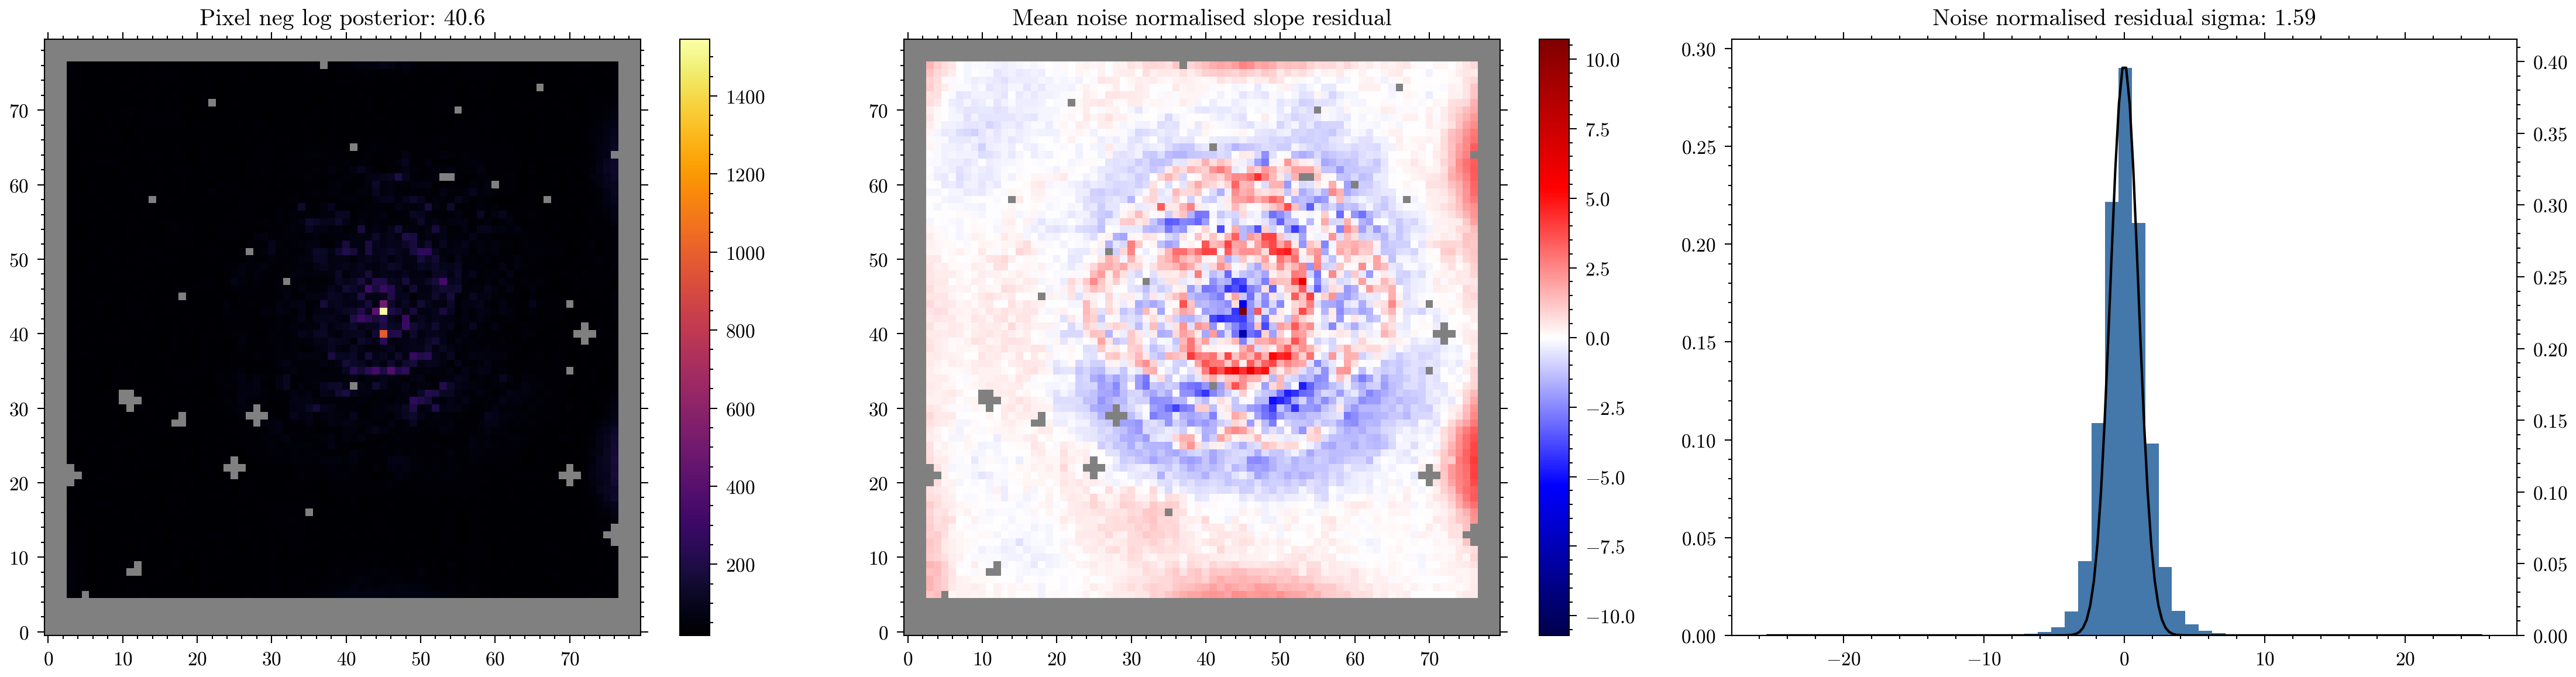

F430M Science IO 18
Loss: 21.450


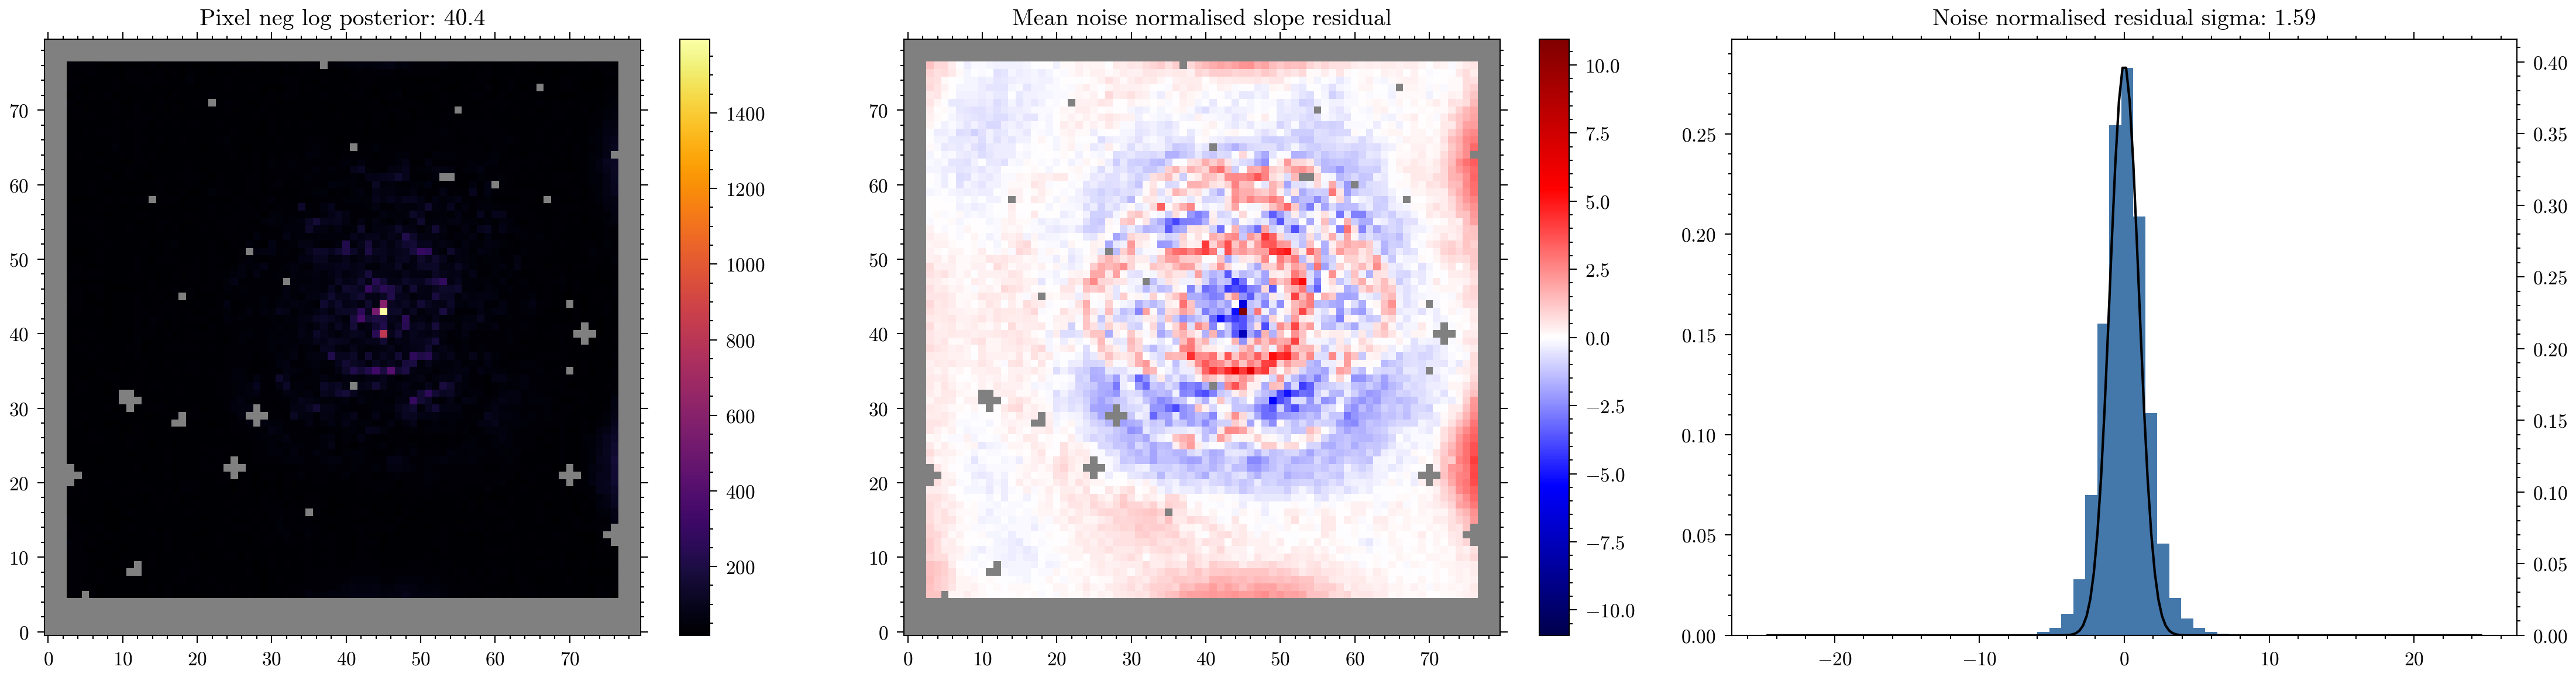

F430M Science IO 18
Loss: 21.161


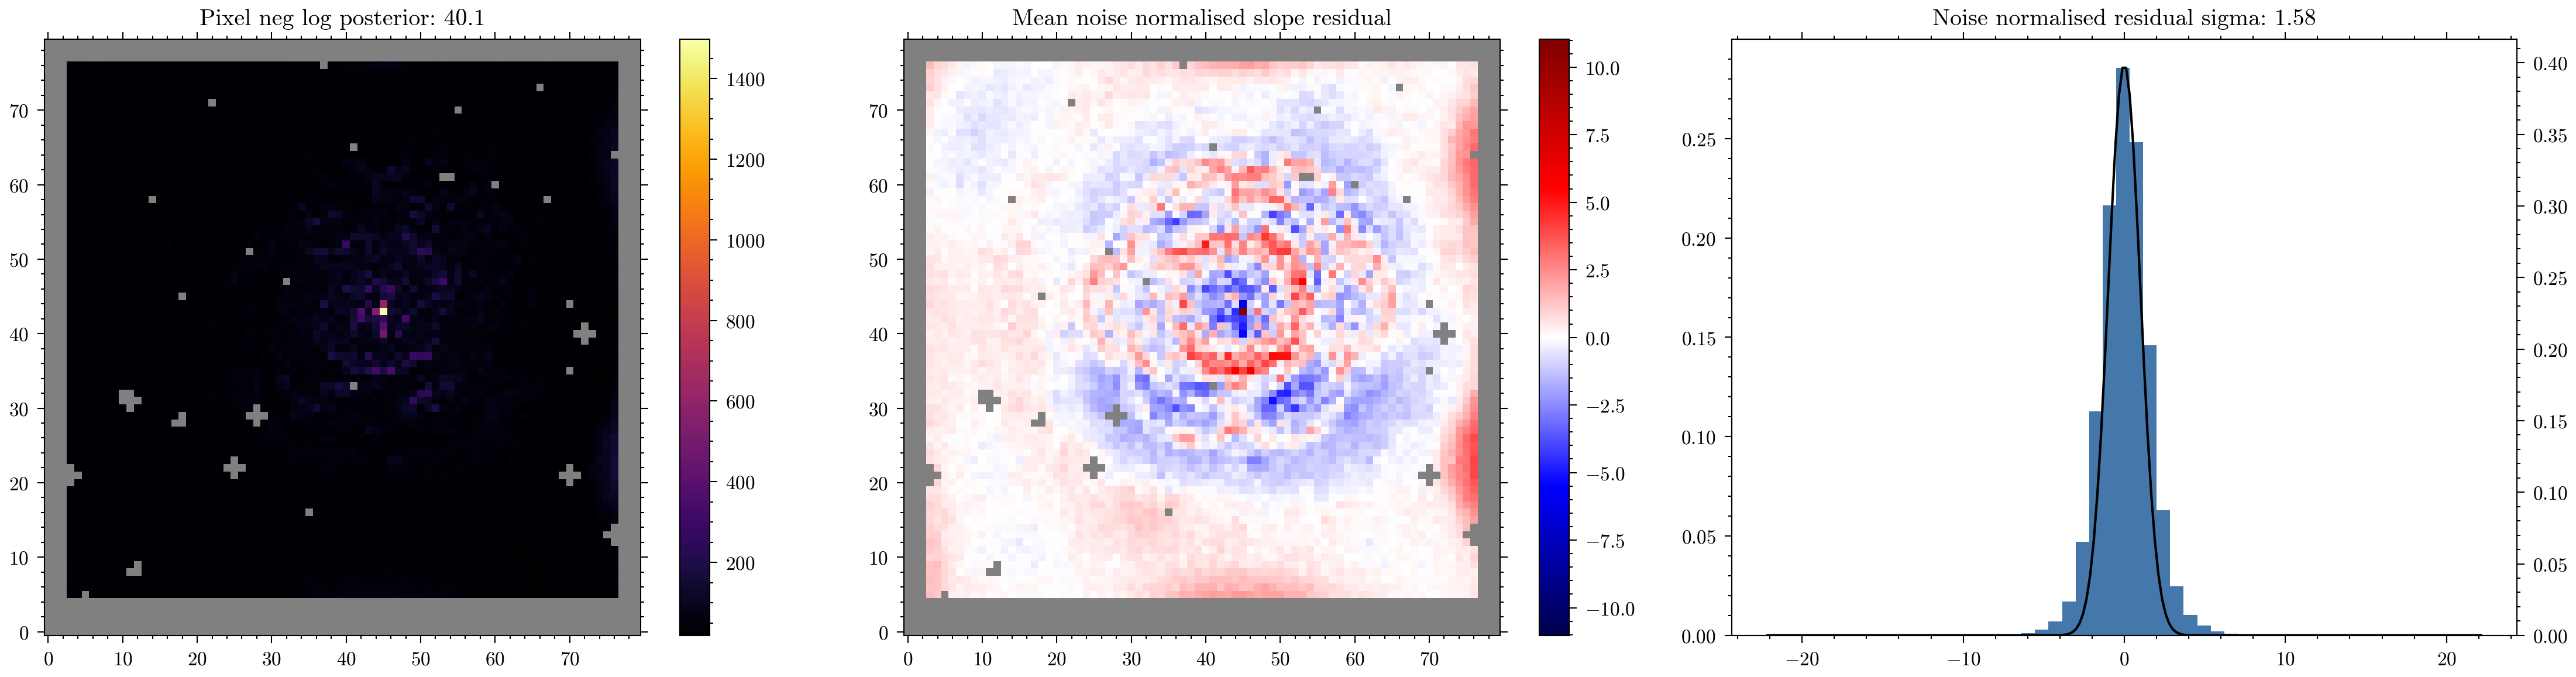

F430M Calibrator HD 2236 12
Loss: 8.207


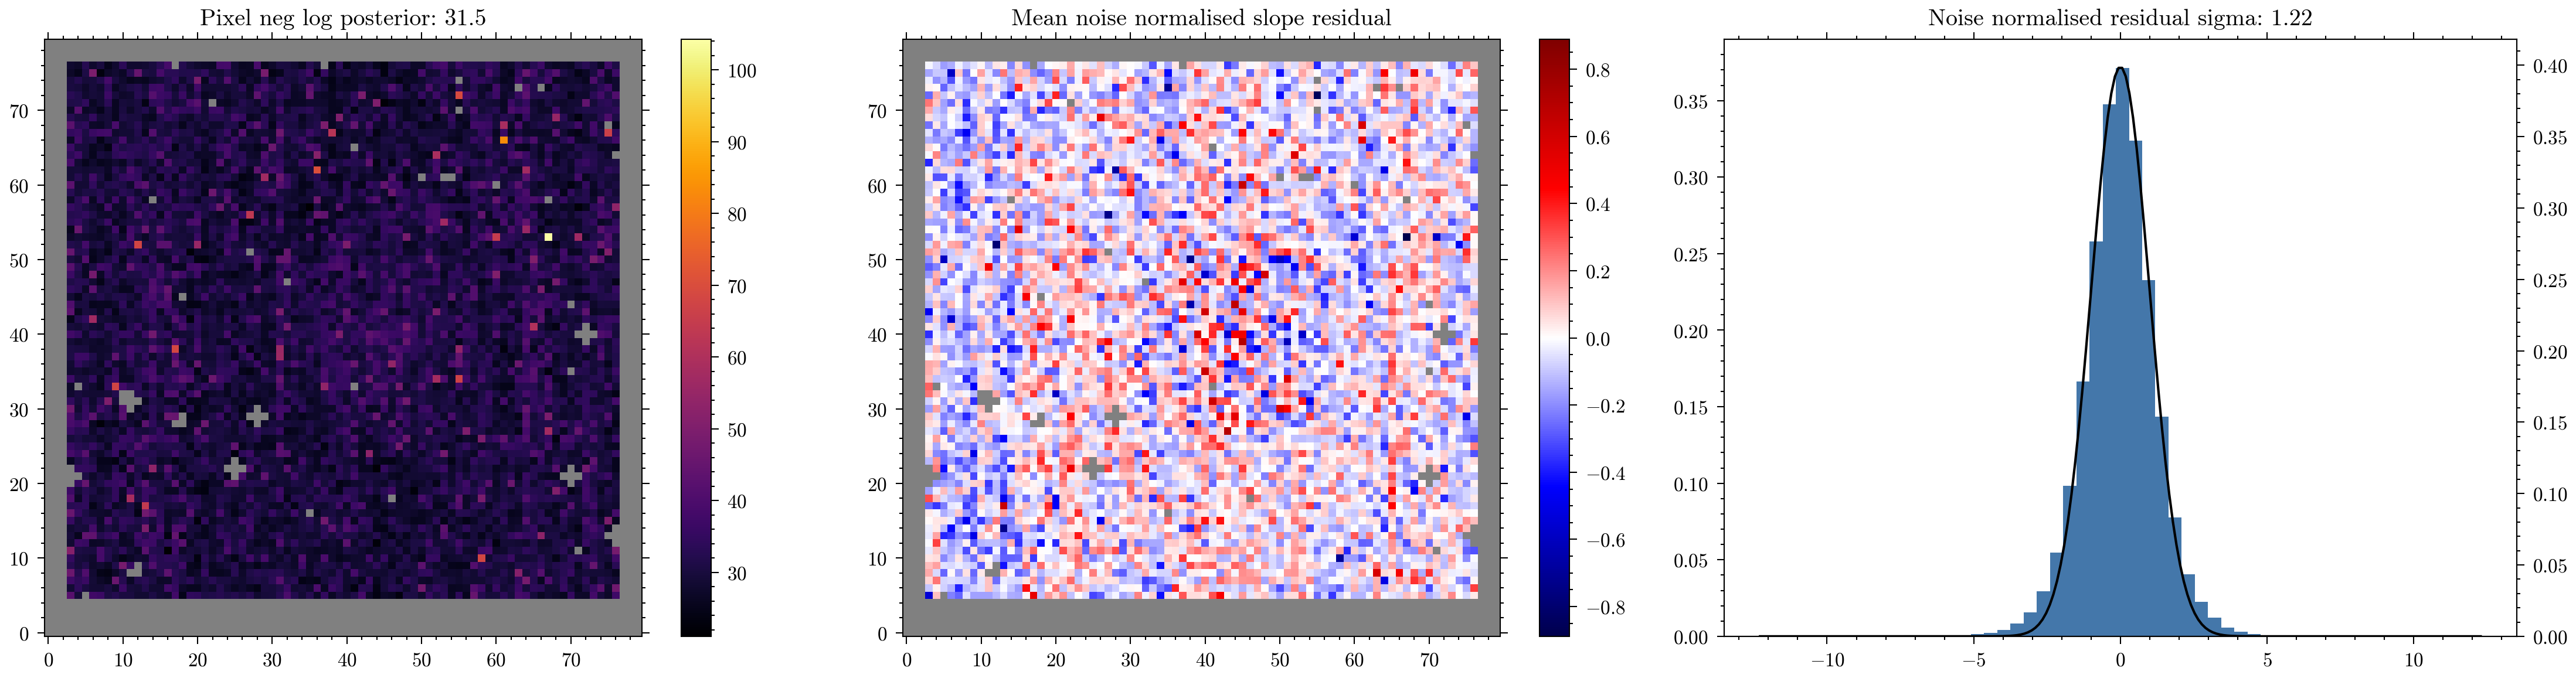

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in fits:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            print(f"Loss: {trainer.loss_fn(final_model, exp)[0]:.3f}")
            amigo.plotting.summarise_fit(final_model, exp)

## Results

In [ ]:
import planetmapper
import scipy

features = {
    "seth": (132, -5.3),  # long [deg], lat [deg]
    "P197": (108.8, -47.3),
    "masubi": (52.6, -45),
    "leizi": (44.93, 13.48),
    # "leizi": (-315.074, 13.48),
    "amirani": (115.2, 24.0),
    # "subobs": (--107.57361768, 2.60587485),
}
# https://iopscience.iop.org/article/10.3847/PSJ/ad4346/pdf


def plot_io_with_ephemeris(
    ax,
    array,
    exp,
    data_dir,
    pixel_scale,
    roll_angle_degrees=0.00,
    legend=False,
    points=None,
    **kwargs
):

    body = planetmapper.Observation(data_dir + exp.filename + "_uncal.fits")
    if points is not None:
        body.coordinates_of_interest_lonlat = points

    def coordinate_func(ra, dec):
        x, y = body.radec2angular(ra, dec)
        return -x, y

    body.plot_wireframe_custom(
        # body.plot_wireframe_angular(
        ax,
        coordinate_func=coordinate_func,
        # aspect_adjustable="box",
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=30,
        grid_lat_limit=75,
        formatting={
            # "limb": {
            #     "linestyle": "--",
            #     "linewidth": 0.8,
            #     "alpha": 0.8,
            #     "color": "white",
            # },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.3,
                "color": "k",
            },
            "equator": {
                "color": "r",
                "linewidth": 1,
                "color": "r",
                "label": "equator",
                # "alpha": 0.0,
            },
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.0,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "gold",
                "marker": "^",
                "facecolors": "none",
                # "markeredgecolor": "red",
                "s": 10,
                "label": "volcano",
            },
            "limb_illuminated": {"color": "b", "alpha": 0.0},
        },
    )

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper left",
        )

    im = plot_result(
        ax,
        array,
        pixel_scale=pixel_scale,
        roll_angle_degrees=roll_angle_degrees,
        show_diff_lim=True,
        **kwargs,
    )

    return im


def plot_diffraction_limit(model, ax=None, OOP=False):
    effective_wl = np.dot(
        model.source_spectrum.wavelengths, model.source_spectrum.weights
    )
    diff_lim = dlu.rad2arcsec(effective_wl / model.optics.diameter)
    scale_length = diff_lim

    scale_bar_x = -0.7
    scale_bar_y = scale_bar_x
    fontdict = {
        "fontstyle": "normal",
        "color": "hotpink",
        "weight": "demi",
        "size": 7,
    }

    if OOP and ax is not None:
        ax.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        ax.text(
            scale_bar_x + scale_length / 2 - 0.075,
            scale_bar_y + 0.03,
            r"$\lambda / D$",
            **fontdict,
        )
        return ax

    else:
        plt.plot(
            [scale_bar_x, scale_bar_x + scale_length],
            [scale_bar_y, scale_bar_y],
            color="hotpink",
            linewidth=2,
        )
        plt.text(
            scale_bar_x + scale_length / 2 - 0.046,
            scale_bar_y + 0.02,
            r"$\lambda / D$",
            **fontdict,
        )


def compute_com_physical(array, pixel_scale):
    """
    Compute the center of mass of a 2D array, assuming the center of the array is at (0, 0).

    Parameters:
    - array: 2D numpy array representing the mass distribution.
    - pixel_scale: The physical scale of each pixel (e.g., in units per pixel).

    Returns:
    - com_physical: The center of mass in physical coordinates, assuming (0, 0) at the center of the array.
    """
    # Compute the center of mass in pixel indices
    com_index = np.array(scipy.ndimage.center_of_mass(numpy.array(array)))

    # Calculate the center of the array in pixel indices
    array_center = np.array(array.shape) / 2 - 0.5  # (rows/2 - 0.5, cols/2 - 0.5)

    # Convert to physical coordinates
    com_physical = (com_index - array_center) * pixel_scale

    return np.array(
        [-com_physical[1], com_physical[0]]
    )  # Return (x, y) in physical coordinates

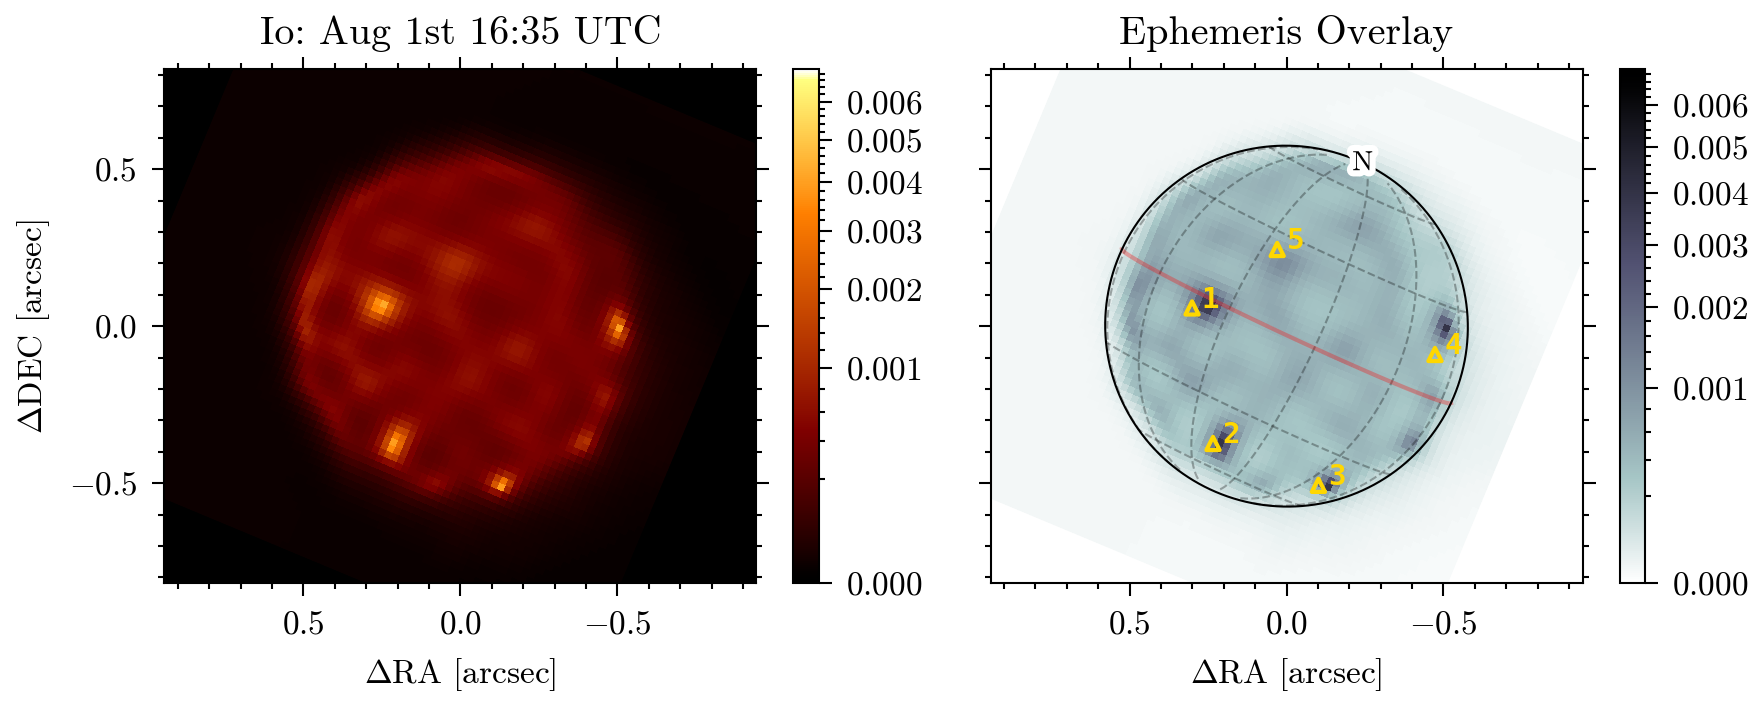

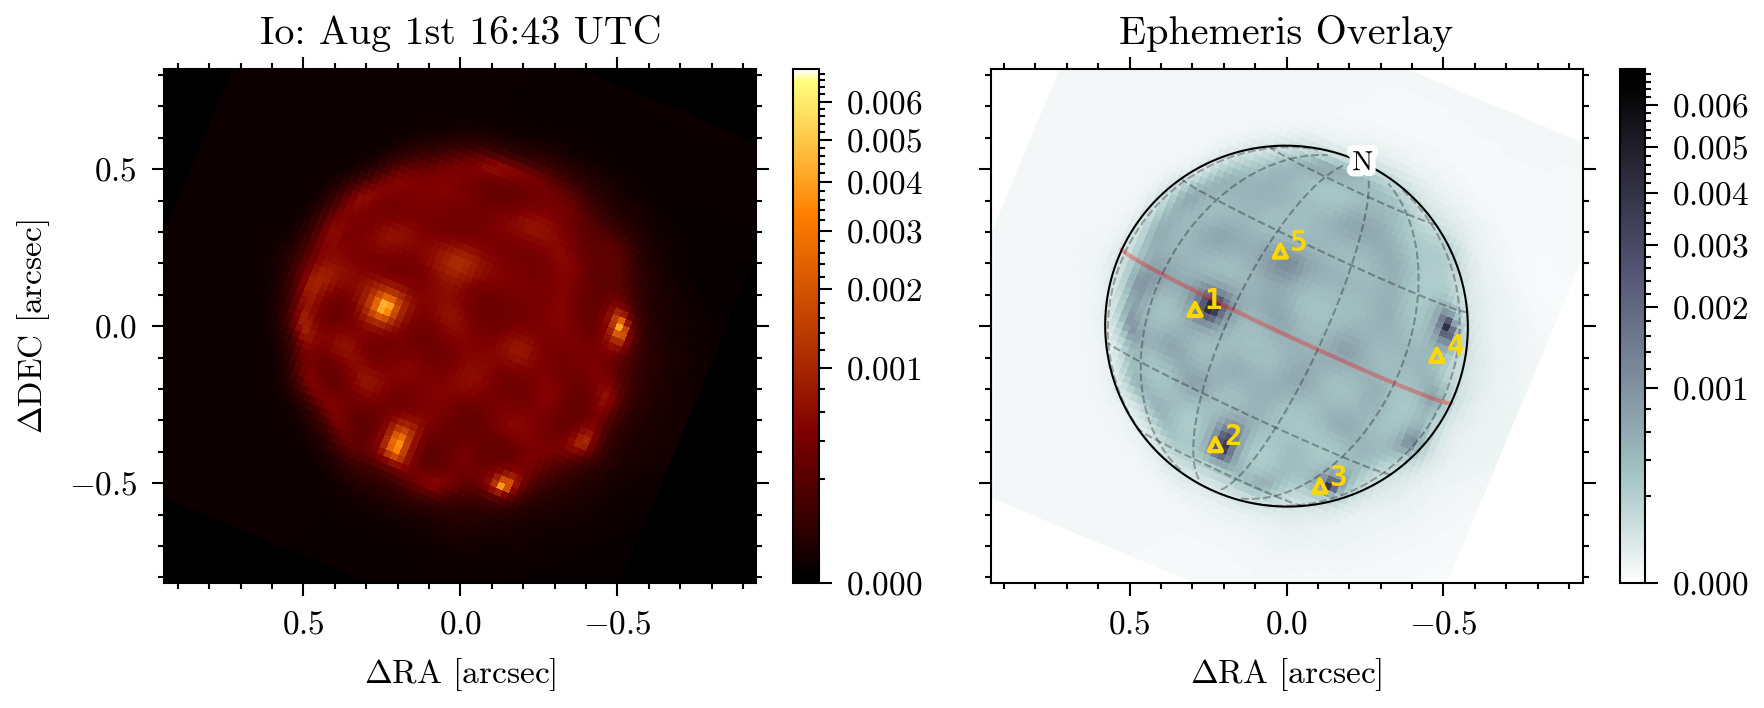

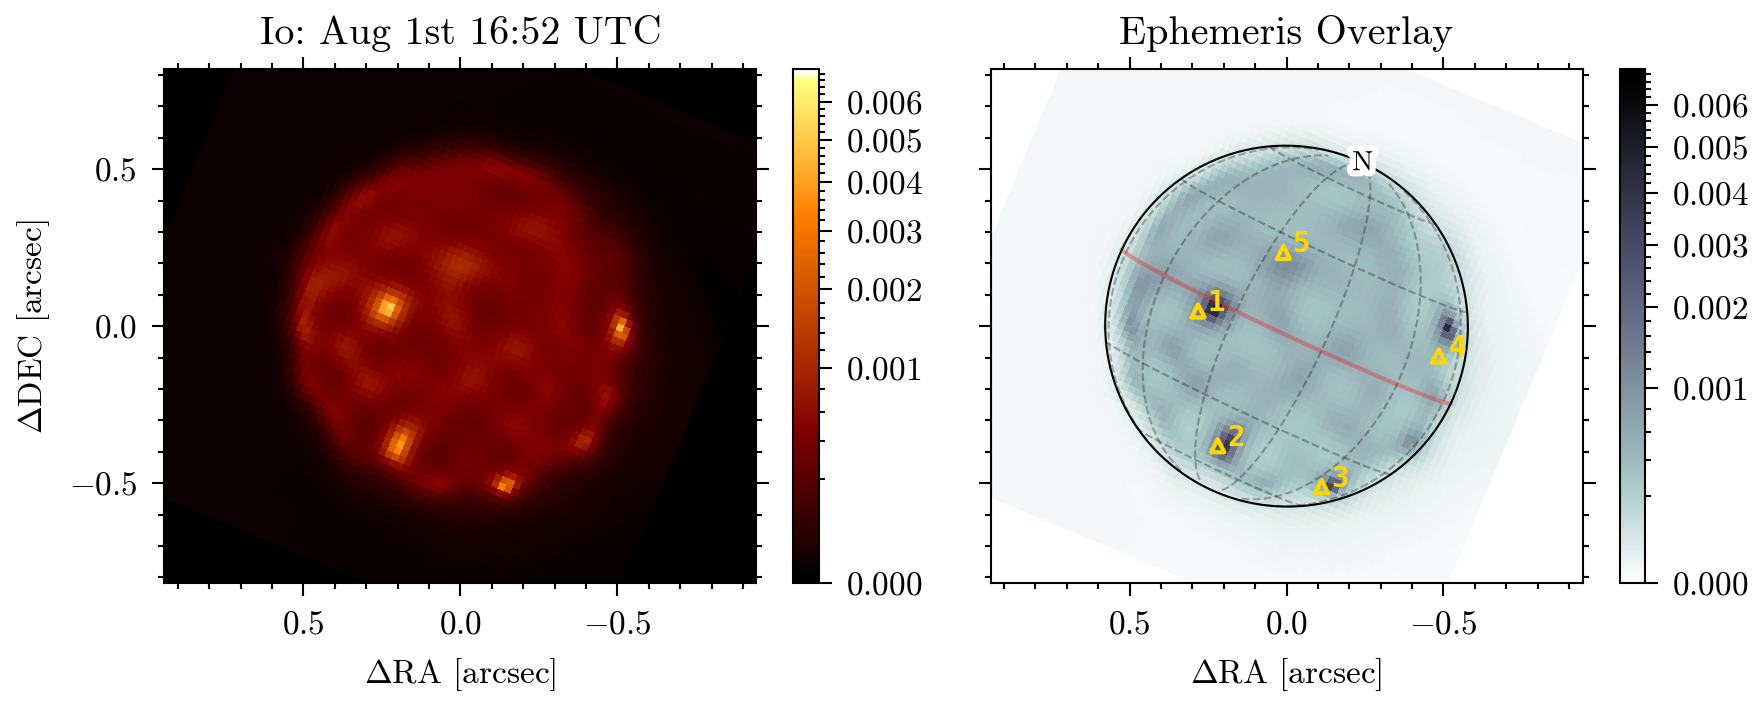

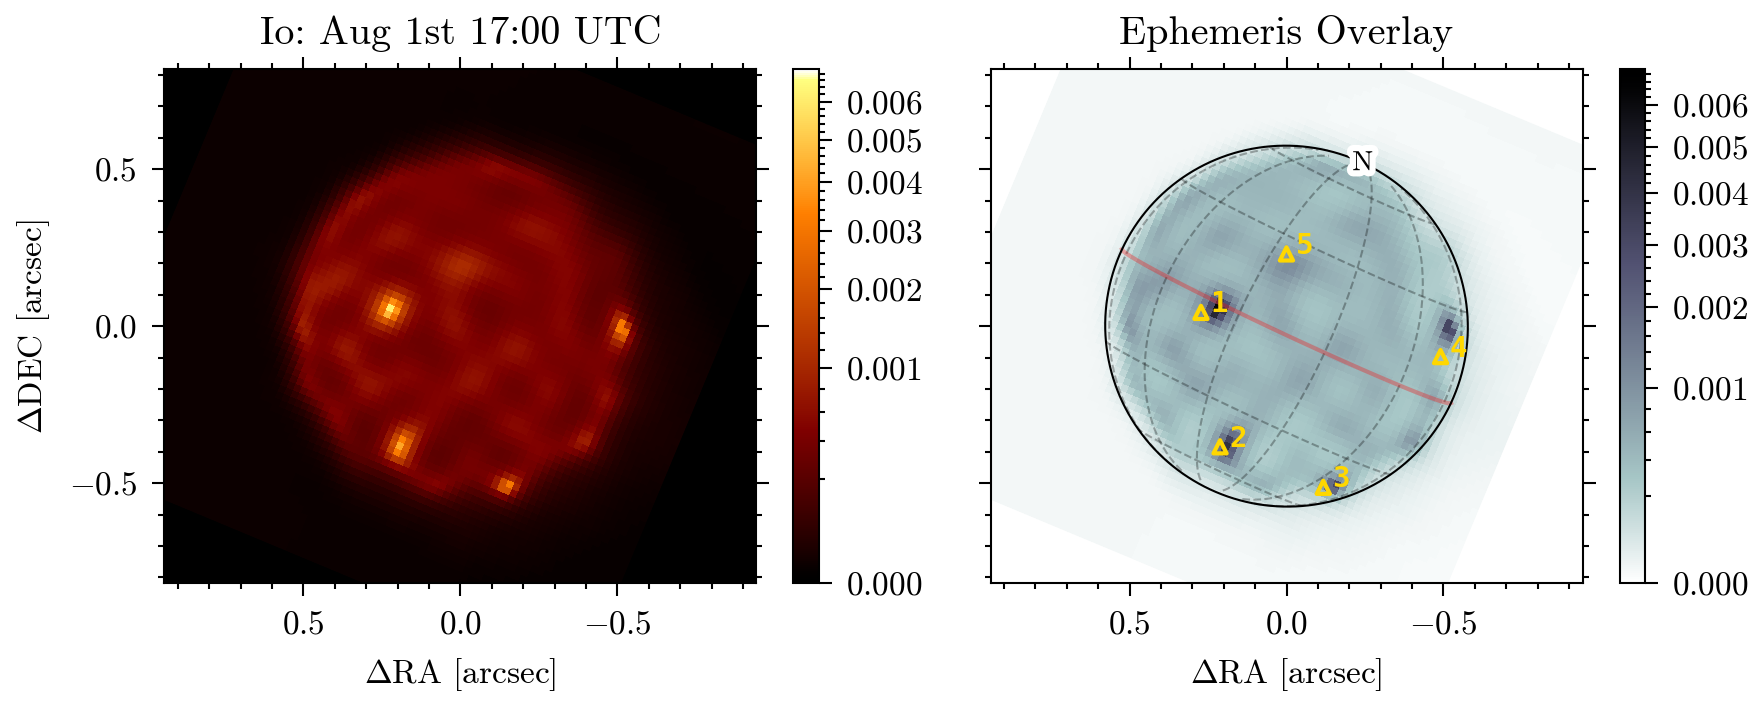

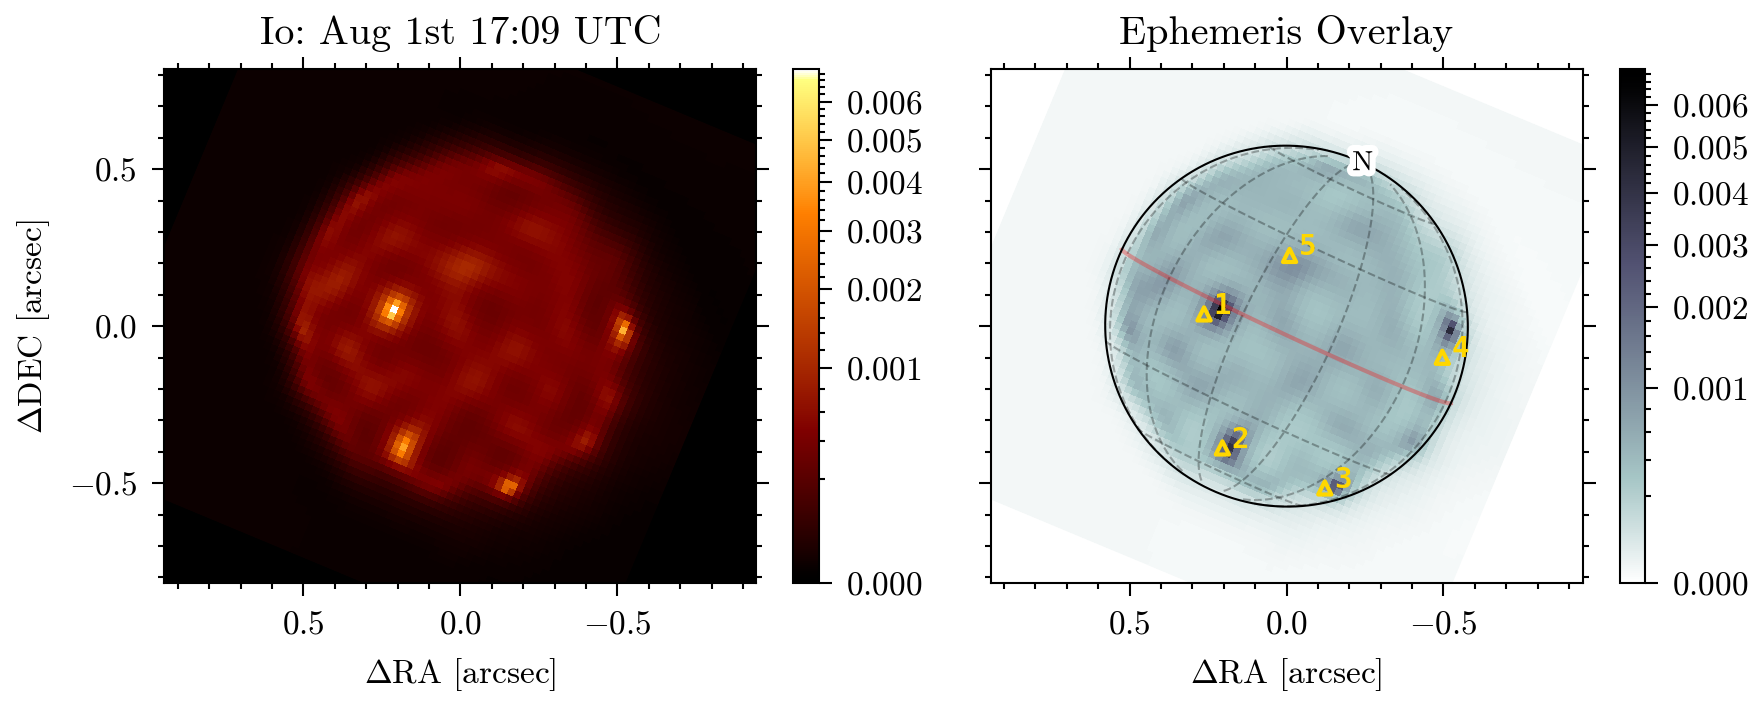

In [ ]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")


result_model = result.model


io_peak_flux = np.array([result_model.get_distribution(exp) for exp in sci_fits]).max()
clip_value = 0.001

save_dir = "gifs/spinning_io/"
for exp, file in zip(sci_fits, sci_files):

    dist = result_model.get_distribution(exp)

    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)
    c0 = plot_result(
        ax[0],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.45,
        roll_angle_degrees=-exp.parang,
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        ax[1],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-exp.parang,
        scale=source_size / 75.0,
        axis_labels={
            "xlabel": r"$\Delta$RA [arcsec]",
            "ylabel": "",
        },
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    eps = 3e-2
    for i, (x, y) in enumerate(coords):  # i should now correctly track the index
        ax[1].text(
            x - eps,
            y,
            f"{i+1}",
            fontsize=7,
            c="gold",
            fontfamily="monospace",
            fontweight="bold",
        )  # Use i in the label

    fig.colorbar(c0)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    ax[0].set_title(f"Io: Aug 1st {time.ymdhms[3]:02}:{time.ymdhms[4]:02} UTC")
    ax[1].set_title(f"Ephemeris Overlay")

    plt.tight_layout()
    fig.colorbar(c1, ax=ax[1])
    plt.savefig(output_path + f"{time.isot}.png", dpi=300)
    # plt.close()
    plt.show()

dorito.plotting.create_gif_from_dir(output_path, "io.gif", duration=0.5)

In [ ]:
dorito.plotting.create_gif_from_dir(output_path, "io.gif", duration=200, loop=0)

In [ ]:
def get_exposing(files, eps=1e0, samples=1e4):

    starts = []
    ends = []
    for file in files:

        # print(file[0].header)
        start = astropy.time.Time(file[0].header["EXPSTART"], format="mjd")
        end = astropy.time.Time(file[0].header["EXPEND"], format="mjd")

        starts.append(mins_past_the_hour(start.mjd))
        ends.append(mins_past_the_hour(end.mjd))

    starts = np.array(starts)
    ends = np.array(ends)
    rang = np.linspace(starts.min() - eps, ends.max() + eps, int(samples))

    exposings = np.array(
        [
            np.where(rang > start, 1.0, 0.0) * np.where(rang < end, 1.0, 0.0)
            for start, end in zip(starts, ends)
        ]
    )

    return rang, exposings


def mins_past_the_hour(mjd):
    # Reference time: 5:00 PM (17:00) on August 1st, 2022 UTC
    ref_time = astropy.time.Time("2022-08-01 16:00:00", format="iso", scale="utc")

    # Convert input MJD to an astropy Time object
    current_time = astropy.time.Time(mjd, format="mjd", scale="utc")

    # Compute time difference in minutes
    delta_minutes = (current_time - ref_time).to("min").value

    return delta_minutes

/tmp/ipykernel_409653/4049856444.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


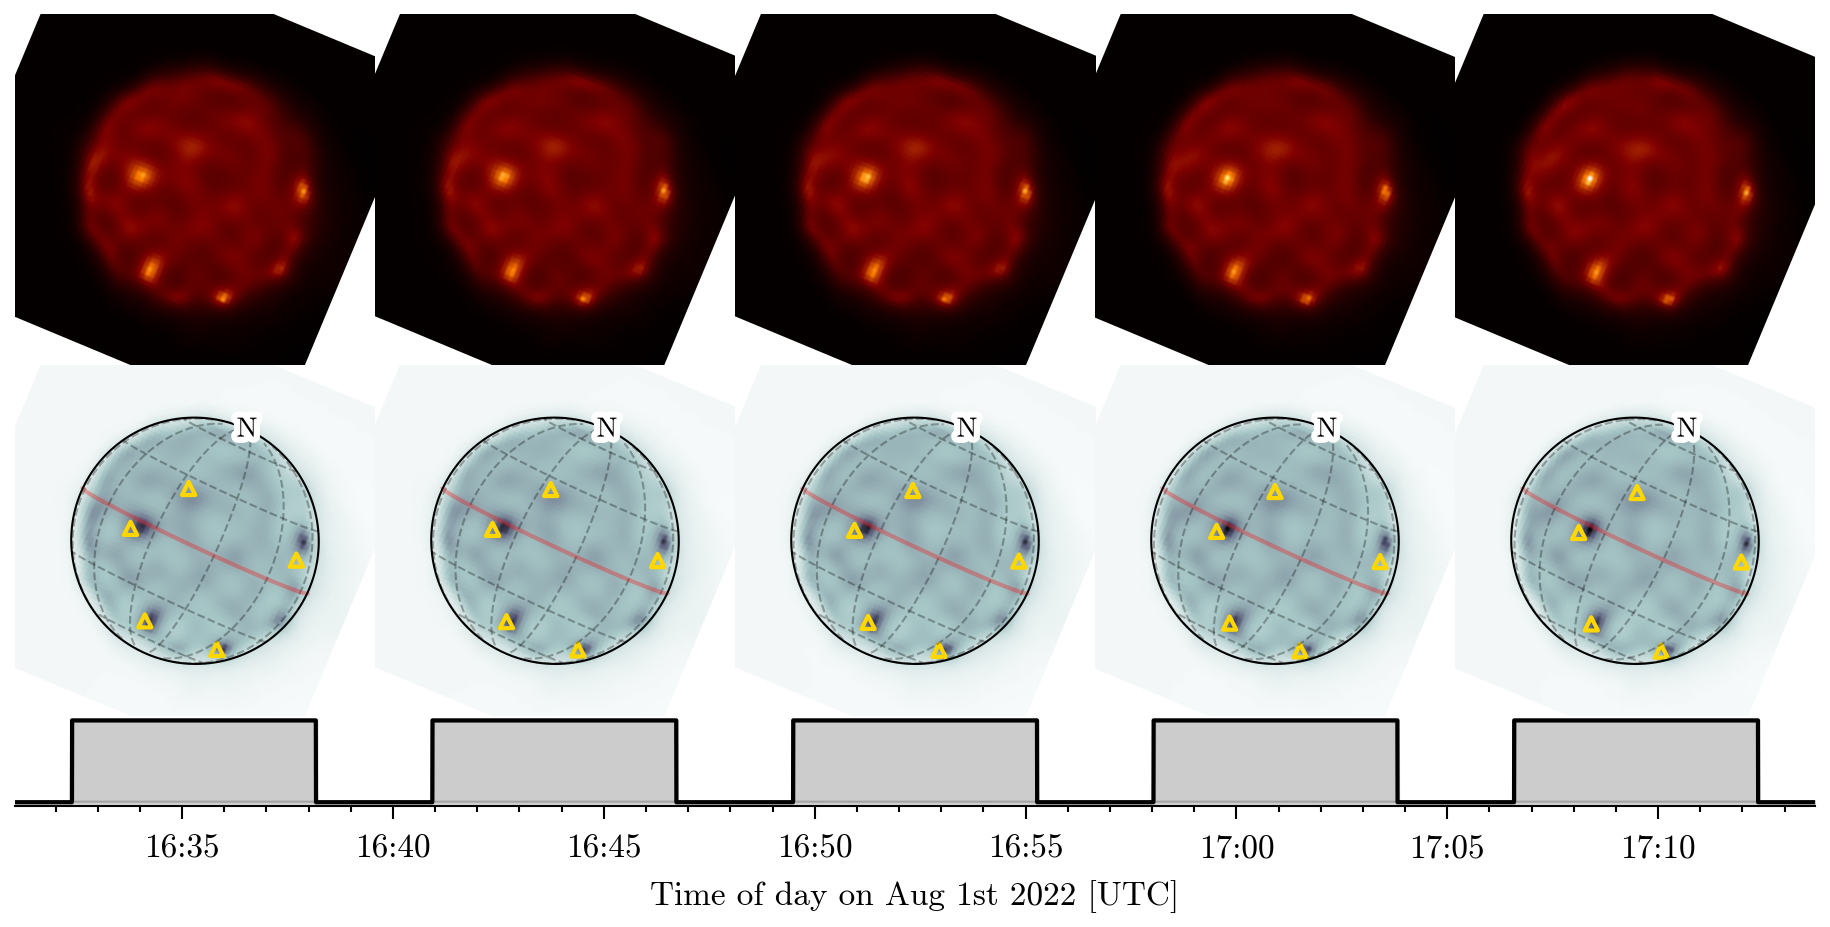

In [ ]:
%matplotlib inline

rang, exposings = get_exposing(sci_files, eps=1.35)
exposing = np.sum(exposings, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(6, 3), gridspec_kw={"hspace": 0.0, "wspace": 0.0, "left":0, "right":1.})

# Adjust layout first
plt.tight_layout()

fig.subplots_adjust(bottom=0.1)  # Shift everything up to leave space for time axis

# Create a new axes for the time plot — [left, bottom, width, height] in figure fraction
time_ax = fig.add_axes([0., 0.0, 1., .1])  # Tune values if needed

for col, exp, file in zip(range(len(sci_fits)), sci_fits, sci_files):

    axes[0][col].axis("off")
    axes[1][col].axis("off")

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    # axes[0][col].set(title=convert_time(time))

    c0 = plot_result(
        axes[0][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-exp.parang,
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        axes[1][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-exp.parang,
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    # eps = 3e-2
    # for i, (x, y) in enumerate(coords):  # i should now correctly track the index
    #     axes[1][col].text(
    #         x - eps,
    #         y,
    #         f"{i+1}",
    #         fontsize=7,
    #         c="gold",
    #         fontfamily="monospace",
    #         fontweight="bold",
    #     )  # Use i in the label

time_ax.plot(rang, exposing, 'k')
time_ax.fill_between(rang, exposing, color='k', alpha=0.2)
time_ax.spines['top'].set_visible(False)
time_ax.spines['right'].set_visible(False)
time_ax.spines['left'].set_visible(False)
time_ax.tick_params(axis="x", which="both", top=False)
time_ax.set(
    xlim=(rang.min(), rang.max()),
    xlabel="Time of day on Aug 1st 2022 [UTC]",  # Set the x-axis label
    xticks=range(35, 75, 5),
    xticklabels=["16:35", "16:40", "16:45", "16:50", "16:55", "17:00", "17:05", "17:10"],
    yticks=[],
    )


    # time_ax.axis("off")

plt.show()

# plt.show()

In [ ]:
def lcurve_sweep(
    regulariser: str,  # e.g. "L1", "L2", "TV", "QV", "ME", "SF"
    coeffs,
    reg_func_dict,
    trainer,
    model,
    optimisers,
    epochs,
    exposures,
):
    """
    Function to find an optimal regularisation hyperparameter using the l-curve method.
    """

    @zdx.filter_jit
    def calc_balance(model, exposures, args, coeff):
        return np.array(
            [
                dorito.stats.prior_data_balance(model, exp, args, coeff)
                for exp in exposures
            ]
        ).sum(0)

    balances = []
    results = []

    args = {"reg_dict": {regulariser: None}, "reg_func_dict": reg_func_dict}

    for coeff in coeffs:
        print(f"Regulariser: {regulariser}, Coefficient: {coeff:.2e}")

        args["reg_dict"][regulariser] = coeff

        result = trainer.train(
            model=model,
            optimisers=optimisers,
            epochs=epochs,
            batches=exposures,
            args=args,
        )

        balance = calc_balance(result.model, exposures, args, coeff)
        balances.append(balance)

        results.append(result)

    return results, np.array(balances).T

In [ ]:
coeffs = 10 ** np.arange(-6.0, -2.5, 0.5)

results, balances = lcurve_sweep(
    "L1",
    coeffs,
    {"L1": L1_REG},
    trainer=trainer,
    model=model,
    optimisers=config,
    epochs=500,
    exposures=fits,
)

for res, coeff in zip(results, coeffs):
    print(f"{coeff:.2e}")
    summarise_reconstruction(res.model, fits, result=res)

In [ ]:
# for res, coeff in zip(results, coeffs):
#     print(f"{coeff:.2e}")
#     summarise_reconstruction(res.model, fits, result=res)

In [ ]:
def plot_lcurve(balances, coeffs, regulariser):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    sc = ax.scatter(
        balances[0],
        balances[1] / coeffs,
        # linestyle="--",
        # marker="o",
        s=3,
        c=coeffs,
        norm=mpl.colors.LogNorm(),
        cmap="tab20",
    )
    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Data Likelihood",
        ylabel="Prior Likelihood",
        title=f"L-curve: {regulariser}",
    )
    plt.colorbar(
        sc,
        label=r"Regularisation Coefficient $\lambda$",
        ticks=10.0 ** np.arange(-10, 15, 1),
    )
    plt.tight_layout()
    plt.show()


plot_lcurve(balances, coeffs, "L1 on wavelets")

In [ ]:
for r, c in zip(results, coeffs):

    ticks = [-0.5, 0, 0.5]
    exp = sci_fits[0]

    try:
        dist = r.model.get_distribution(exp)
    except:
        dist = exp.get_distribution(r.model)

    fig, ax = plt.subplots(figsize=(3, 2))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=pscale(model),
        roll_angle_degrees=-rolls[exp.filename],
        cmap="afmhot_u",
        power=0.3,
        vmin=0,
        ticks=ticks,
    )
    # print(b)
    ax.set(title=f"{c:.2e}")
    ax.axis("off")
    plt.show()